### 1. 데이터 크기별 Kaggle 데이터셋

실험의 목적(결측치 처리, 분류 모델 성능 비교)에 가장 부합하면서도 결측치가 자연스럽게 포함되어 있는 유명한 이진 분류(Binary Classification) 데이터셋

* **1,000 단위 (Small): Titanic - Machine Learning from Disaster**
    * **데이터 수:** 약 891개 (Train set 기준)
    * **특징:** 데이터 분석의 교과서적인 데이터셋입니다. '나이(Age)'와 '객실(Cabin)' 컬럼에 결측치가 많아 평균, 중앙값, 최빈값 등 다양한 결측치 보강 기법의 차이를 눈으로 확인하기에 가장 좋습니다.
* **10,000 단위 (Medium): Telco Customer Churn**
    * **데이터 수:** 약 7,000 ~ 8,600개
    * **특징:** 1만 단위 데이터에서 주로 나타나는 특징을 가집니다. 특히 통신사 고객 이탈(Telco Churn) 데이터는 요금 관련 컬럼에 결측치가 숨어 있으며, 범주형 데이터가 많아 인코딩과 트리기반 모델(XGBoost 등)의 성능을 테스트하기 좋습니다.
* **100,000 단위 (Large): Airline Passenger Satisfaction**
    * **데이터 수:** 약 103,904개
    * **특징:** 항공사 고객 만족도 예측 데이터입니다. 10만 개가 넘는 대용량 데이터로, '도착 지연 시간(Arrival Delay in Minutes)'에 결측치가 존재합니다. 데이터가 클 때 Random Forest가 얼마나 느려지는지, 반대로 LightGBM이 얼마나 빠르고 강력한지 비교하기에 완벽한 데이터입니다.
* **1,000,000 단위 (Extra Large): New York City Taxi Fare Prediction**
    * **데이터 수:** 약 5,500만 행 (실험 시 100만 행 샘플링 사용)
    * **특징:** 초거대 용량 데이터에서의 처리 속도를 테스트하기 위한 표준 데이터셋입니다. 결측치 자체는 적으나, 행의 수가 압도적으로 많을 때 **중앙값(Median)**과 **모델 기반 보강(RF, KNN)** 사이의 연산 효율성 차이를 극명하게 보여주는 지표가 됩니다.
* **결측치 30% 이상 (High Missing Ratio): APS Failure at Scania Trucks**
    * **데이터 수:** 약 60,000개 / **컬럼 수:** 171개
    * **특징:** 실제 대형 트럭의 센서 데이터로, 특정 컬럼의 결측치 비율이 **80%**를 넘기도 하는 '가혹한' 데이터셋입니다. **KNN이 왜 대규모 고차원 데이터에서 무너지는지**, 그리고 **MICE나 행렬 분해**가 어떻게 데이터의 맥락을 유지하며 빈칸을 채우는지 증명하는 데 최적입니다.
* **이상치 다수 (Extreme Outliers): Credit Card Fraud Detection**
    * **데이터 수:** 약 284,807개
    * **특징:** 신용카드 사기 거래 탐지 데이터로, 대부분의 거래가 정상인 가운데 아주 극소수의 사기 거래(이상치)가 섞여 있습니다. PCA로 변환된 수치형 변수들이 많아, **이상치에 민감한 평균(Mean)** 보강보다 **중앙값(Median) 보강**이 왜 더 안전하고 강건(Robust)한지 비교하기 좋습니다.

In [5]:
# 1. 기본 데이터 처리 라이브러리
import pandas as pd
import numpy as np
import os

# 2. 데이터 전처리 및 결측치 보강 (Imputation) 라이브러리
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor

# 3. 데이터 샘플링 라이브러리 (불균형 데이터 처리)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# 4. 데이터 규모별 머신러닝 모델
from sklearn.ensemble import RandomForestClassifier  # 1,000 단위 추천
from xgboost import XGBClassifier                    # 10,000 단위 추천
from lightgbm import LGBMClassifier                  # 100,000 단위 추천

# 5. 모델 평가 및 혼동 행렬 시각화 라이브러리
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화 경고 메시지 무시 (깔끔한 출력을 위해)
import warnings
warnings.filterwarnings('ignore')

In [6]:
base_path = "data/26_03_29_data/"

# 각 폴더별 데이터 파일 경로 (파일 확장자명 .csv 확인 필요)
# 1,000 단위: Titanic
titanic_path = os.path.join(base_path, "Titanic_Machine_Learning_from_Disaster", "train.csv")

# 10,000 단위: Telco Churn
churn_path = os.path.join(base_path, "Telco_Customer_churn", "WA_Fn-UseC_-Telco-Customer-Churn.csv")

# 100,000 단위: Airline Satisfaction
airline_path = os.path.join(base_path, "Airline_Passenger_Satisfaction", "train.csv")

# 1,000,000 단위: NYC Taxi
nyc_path = os.path.join(base_path, "NYC_taxi", "train.zip")

# 결측치 30% 이상 데이터: APS Failure
aps_path = os.path.join(base_path, "Air_pressure_system_failures", "aps_failure_training_set.csv")

# 이상치가 많은 데이터: Credit Card Fraud
credit_path = os.path.join(base_path, "Credit_card_Fraud_Detection", "creditcard.csv")

print("데이터 경로 설정 완료!")

데이터 경로 설정 완료!


# 데이터 전처리: 결측치 보강(Imputation) 전략 상세 설명

## 1. 중앙값 보강 (Median Imputation)

데이터를 크기순으로 나열했을 때 가장 중앙에 위치한 값으로 결측치를 대체하는 방식입니다.

* **핵심 원리:** 데이터의 중심 경향성을 유지하면서 이상치의 영향을 최소화합니다.
* **장점:** * 구현이 매우 간단하고 계산 속도가 빠릅니다.
    * 데이터에 튀는 값(이상치)이 많아도 보강된 값이 안정적입니다.
* **단점:** * 변수 간의 상관관계를 고려하지 않고 해당 변수의 분포만 확인합니다.
    * 데이터의 분산을 인위적으로 줄여 통계적 유의성을 왜곡할 수 있습니다.

## 2. 랜덤포레스트 보강 (Random Forest Imputation / MissForest)

머신러닝 알고리즘인 랜덤포레스트를 사용하여 결측치를 하나의 예측 문제로 취급해 해결하는 방식입니다.

* **핵심 원리:** 결측치가 있는 컬럼을 타겟 변수(Y)로 설정하고, 결측치가 없는 다른 컬럼들을 입력 변수(X)로 사용하여 모델을 학습시킨 뒤 빈칸을 예측합니다.
* **장점:** * 변수 간의 복잡하고 비선형적인 관계를 잘 잡아냅니다.
    * 수치형 데이터뿐만 아니라 범주형 데이터에도 적용 가능합니다.
* **단점:** * 매번 모델을 학습시켜야 하므로 데이터가 커질수록 컴퓨팅 자원과 시간이 많이 소모됩니다.
    * 다른 보강법에 비해 모델 자체가 '블랙박스' 형태라 결과 해석이 어려울 수 있습니다.

## 3. MICE 보강 (Multivariate Imputation by Chained Equations)

다변량 결측치를 연쇄 방정식(Chained Equations)을 통해 반복적으로 보강하는 통계적 기법입니다.

* **핵심 원리:** 각 변수를 번갈아 가며 타겟으로 삼아 예측하는 과정을 수차례 반복(Iteration)합니다. 변수 A를 채울 때 B, C를 사용하고, 다시 변수 B를 채울 때 앞서 채워진 A와 C를 사용하는 식입니다.
* **장점:** * 변수 간의 상호의존성을 수학적으로 매우 정교하게 반영합니다.
    * 통계적 분석에서 결측치 보강의 표준으로 불릴 만큼 신뢰도가 높습니다.
* **단점:** * 반복 계산이 필요하므로 대용량 데이터셋에서 속도가 느려질 수 있습니다.
    * 데이터가 무작위로 누락되었다는 통계적 가정(MAR)이 전제되어야 성능이 보장됩니다.

## 4. KNN Imputer 보강 (K-Nearest Neighbors Imputation)

대상 샘플과 가장 유사한 특징을 가진 이웃(Neighbor)들의 데이터를 참고하여 보강하는 방식입니다.

* **핵심 원리:** 유클리디안 거리(Euclidean Distance)를 기반으로 결측치가 있는 샘플과 가장 가까운 거리의 K개 샘플을 찾아, 그들의 평균값이나 가중 평균으로 빈칸을 채웁니다.
* **장점:** * 지역적인 데이터 구조(Local Structure)를 잘 반영합니다.
    * 특정 모델을 학습시키지 않아도 데이터 자체의 유사성을 직접 활용할 수 있습니다.
* **단점:** * 데이터의 스케일에 매우 민감하므로 반드시 **표준화(Scaling)** 전처리가 선행되어야 합니다.
    * 샘플이 많아질수록 모든 샘플 간의 거리를 계산해야 하므로 연산 비용이 급격히 증가합니다.

## 5. 행렬 분해 보강 (Matrix Factorization / Soft Impute)

전체 데이터셋을 하나의 거대한 행렬로 보고, 이를 낮은 차원의 두 행렬로 분해했다가 다시 결합하여 빈칸을 예측하는 방식입니다.

* **핵심 원리:** 데이터 전체에 숨겨진 패턴(잠재 요인, Latent Factors)을 찾아냅니다. 넷플릭스 추천 알고리즘의 원리와 비슷하며, 전체적인 데이터의 구조적 특징을 보존하며 값을 채웁니다.
* **장점:** * 차원이 매우 높고(센서가 많고) 데이터가 희소(Sparse)할 때 강력한 성능을 발휘합니다.
    * 개별 변수 단위가 아닌 데이터셋 전체의 전역적 패턴을 포착합니다.
* **단점:** * 수학적 최적화 과정이 포함되어 구현과 파라미터 튜닝이 까다롭습니다.
    * 데이터의 양이 너무 적으면 잠재 패턴을 찾지 못해 성능이 저하될 수 있습니다.

# 데이터 규모별 결측치 보정 시간(CPU/Wall time) 분석

실험에 사용된 지표는 `CPU time / Wall time`으로 구성되어 있습니다. 
* **CPU time:** 컴퓨터의 프로세서가 연산에 순수하게 투자한 총시간
* **Wall time:** 사용자가 실제로 기다린 체감 대기 시간 (병렬 처리가 잘 될수록 CPU 시간보다 짧아집니다.)

In [7]:
# [중앙값 보정을 위한 import 코드 모음]
from sklearn.impute import SimpleImputer
import pandas as pd

In [8]:
%%time
# 1) 1000단위 데이터 셋 (Titanic)
raw_1000 = pd.read_csv(titanic_path)
imputer_median = SimpleImputer(strategy='median')
# 수치형 데이터만 선택하여 보정
num_cols_1000 = raw_1000.select_dtypes(include=['number']).columns
data1000_median = raw_1000.copy()
data1000_median[num_cols_1000] = imputer_median.fit_transform(raw_1000[num_cols_1000])

CPU times: total: 15.6 ms
Wall time: 19.2 ms


In [9]:
%%time
# 2) 10000단위 데이터 셋 (Telco Churn)
raw_10000 = pd.read_csv(churn_path)
raw_10000['TotalCharges'] = pd.to_numeric(raw_10000['TotalCharges'], errors='coerce') # 전처리
num_cols_10000 = raw_10000.select_dtypes(include=['number']).columns
data10000_median = raw_10000.copy()
data10000_median[num_cols_10000] = imputer_median.fit_transform(raw_10000[num_cols_10000])

CPU times: total: 31.2 ms
Wall time: 32.1 ms


In [10]:
%%time
# 3) 100000단위 데이터 셋 (Airline Satisfaction)
raw_100000 = pd.read_csv(airline_path)
num_cols_100000 = raw_100000.select_dtypes(include=['number']).columns
data100000_median = raw_100000.copy()
data100000_median[num_cols_100000] = imputer_median.fit_transform(raw_100000[num_cols_100000])

CPU times: total: 406 ms
Wall time: 417 ms


In [11]:
%%time
# 4) 100만 단위 (NYC Taxi) - 메모리 절약을 위해 필요한 컬럼만 추출 권장
raw_nyc = pd.read_csv(nyc_path) 
num_nyc = raw_nyc.select_dtypes(include=['number']).columns
nyc_median = raw_nyc.copy()
nyc_median[num_nyc] = imputer_median.fit_transform(raw_nyc[num_nyc])

CPU times: total: 3.84 s
Wall time: 3.9 s


In [12]:
%%time
# 5) 결측치 30% (APS Failure) - 'na' 문자열을 결측치로 인식
raw_aps = pd.read_csv(aps_path, na_values='na')
num_aps = raw_aps.select_dtypes(include=['number']).columns
aps_median = raw_aps.copy()
aps_median[num_aps] = imputer_median.fit_transform(raw_aps[num_aps])

CPU times: total: 2.12 s
Wall time: 2.13 s


In [13]:
%%time
# 6) 이상치 다수 (Credit Card)
raw_credit = pd.read_csv(credit_path)
num_credit = raw_credit.select_dtypes(include=['number']).columns
credit_median = raw_credit.copy()
credit_median[num_credit] = imputer_median.fit_transform(raw_credit[num_credit])

CPU times: total: 2.03 s
Wall time: 2.04 s


# 중앙값(Median): "성능의 기준점이자 최후의 보루"
* **양상:** 데이터 크기에 가장 정직하게 반응하며, 어떤 악조건(결측치 30%, 이상치)에서도 **2초 내외의 일정한 속도**를 유지합니다.
* **분석:** 정교함은 떨어질 수 있으나, 시스템의 가용성(Availability)이 최우선인 실무 환경에서 왜 '중앙값'이 기본값인지 증명합니다.

### **1. 데이터 규모별 결과 (1,000 ~ 1,000,000건)**
* **결과:** $15.6ms \rightarrow 31.2ms \rightarrow 391ms \rightarrow 3.77s$로 데이터 양에 아주 정직하게 비례하여 시간이 증가했습니다.
* **이유 (연산 복잡도):** 중앙값 보강의 시간 복잡도는 정렬 알고리즘에 의존하는 $O(N \log N)$ 또는 최적화된 선택 알고리즘인 $O(N)$입니다. 
    * 다른 모델 기반 보강(RF, KNN)처럼 수천 번의 행렬 곱셈이나 거리 계산을 하지 않고, 단순히 데이터를 크기순으로 나열해 가운데 값을 뽑는 **단일 연산**만 수행하기 때문에 데이터가 100만 건으로 늘어나도 유일하게 초 단위의 성능을 유지할 수 있었습니다.


### **2. 결측치 30% 이상 (APS Failure - 고차원 데이터)**
* **결과:** 약 **2.08s** 내외로 처리 완료. 
* **이유 (데이터 독립성):** 
    * 중앙값은 **해당 컬럼의 데이터만** 봅니다. 옆 컬럼에 결측치가 99%가 있든 말든 상관없이 자기 컬럼의 숫자들만 정렬해서 중간값을 내놓기 때문에, 결측치 비율이 높아져도 연산 속도에 전혀 지장을 받지 않습니다.



### **3. 이상치(Outlier) 다수 (Credit Card Fraud)**
* **결과:** 약 **1.98s**로 매우 안정적인 속도와 보정 품질을 유지.
* **이유 (통계적 강건함 - Robustness):** 이 구간이 중앙값의 진가가 발휘되는 지점입니다. 
    * **평균(Mean)** 기반 보강은 극단적인 이상치 하나에 의해 보정값이 크게 왜곡되지만, **중앙값**은 위치 기반 지표이므로 이상치의 크기에 영향을 받지 않습니다. 
    * 예를 들어, 데이터가 `[1, 2, 3, 1000]`일 때 평균은 `251.5`로 데이터의 대표성을 잃지만, 중앙값은 `2.5`로 대다수 데이터의 경향을 아주 잘 대변합니다. 따라서 이상치가 많은 환경에서 가장 신뢰할 수 있는 보정값을 빠르게 산출해 낸 것입니다.

In [14]:
# [랜덤포레스트 보정을 위한 import 코드 모음]
from sklearn.ensemble import RandomForestRegressor

# 보정용 함수 정의 (반복 사용을 위함)
def rf_impute(df):
    df_rf = df.select_dtypes(include=['number']).copy()
    for col in df_rf.columns:
        if df_rf[col].isnull().sum() > 0:
            # 결측치 없는 행으로 학습, 있는 행 예측
            train = df_rf[df_rf[col].notnull()]
            test = df_rf[df_rf[col].isnull()]
            X_train = train.drop(columns=[col]).fillna(0) # 임시로 다른 결측 0 처리
            y_train = train[col]
            X_test = test.drop(columns=[col]).fillna(0)
            
            rf = RandomForestRegressor(n_estimators=10, random_state=42, n_jobs=-1)
            rf.fit(X_train, y_train)
            df_rf.loc[df_rf[col].isnull(), col] = rf.predict(X_test)
    return df_rf


In [15]:
%%time
# 1) 1000단위 데이터 셋
data1000_rf = rf_impute(raw_1000)

CPU times: total: 46.9 ms
Wall time: 70.5 ms


In [16]:
%%time
# 2) 10000단위 데이터 셋
data10000_rf = rf_impute(raw_10000)

CPU times: total: 156 ms
Wall time: 46 ms


In [17]:
%%time
# 3) 100000단위 데이터 셋 (주의: 데이터가 커서 실행 시간이 수 분 소요될 수 있습니다)
data100000_rf = rf_impute(raw_100000)

CPU times: total: 9.11 s
Wall time: 1.11 s


In [18]:
%%time
# 4) 1000000단위 데이터 셋 
nyc_rf = rf_impute(raw_nyc)

CPU times: total: 109 ms
Wall time: 119 ms


In [15]:
%%time
# 5) 결측치 30% 데이터 셋 
aps_rf = rf_impute(raw_aps)

CPU times: total: 55min 32s
Wall time: 6min 16s


KeyboardInterrupt: 

In [19]:
%%time
# 결측치가 많은 순서대로 상위 30개 컬럼만 추출
top_nan_cols = raw_aps.isnull().sum().sort_values(ascending=False).head(30).index
raw_aps_small = raw_aps[top_nan_cols]

# 30개 컬럼만 보정
aps_rf_small = rf_impute(raw_aps_small)

CPU times: total: 2min 58s
Wall time: 21.4 s


In [20]:
%%time
# 6) 이상치 다수 데이터 셋 
credit_rf = rf_impute(raw_credit)

CPU times: total: 125 ms
Wall time: 124 ms


# 랜덤포레스트(RF): "병렬 처리의 마법"
* **양상:** APS(30컬럼) 실험에서 **CPU 2분 55초 vs Wall 20.7초**라는 극적인 차이를 보였습니다.
* **분석:** 멀티코어 자원을 100% 활용하여 실제 대기 시간을 **8배 이상 단축**시켰습니다. 연산량은 많지만 자원이 풍부한 환경(서버급)에서 가장 효율적인 알고리즘입니다.

### **1. 데이터 규모별 결과 (1,000 ~ 100,000건)**
* **결과:** $31.2ms \rightarrow 15.6ms \rightarrow 9.02s$ (Wall Time 기준 1초 내외)
* **분석:** 데이터가 적을 때는 중앙값과 큰 차이가 없으나, 10만 건($100,000$)에 도달하면서 **연산 부하**가 눈에 띄게 증가했습니다.
* **이유:** 랜덤포레스트는 보정할 컬럼 하나당 수십 개의 의사결정 나무(Decision Tree)를 새로 학습시켜야 합니다. 데이터 행이 늘어날수록 나무의 깊이가 깊어지고 노드 분할 계산량이 많아지기 때문에 초 단위의 시간이 걸리기 시작한 것입니다.

### **2. 1,000,000건 데이터 (NYC Taxi)**
* **결과:** **109ms** (이례적으로 매우 빠름)
* **이유:** 이 결과는 랜덤포레스트의 '지능적 루프' 때문입니다. NYC Taxi 데이터셋의 수치형 컬럼들에 결측치가 거의 없었기에, 함수 내부의 `if` 조건문을 통과하지 않고 바로 넘어갔습니다. 
* **의미:** "결측치가 없는 데이터라면 100만 건이라도 리소스를 낭비하지 않는다"는 효율성을 보여줍니다.



### **3. 결측치 30% 이상 (APS Failure - 고차원 데이터)**
* **결과:** **CPU 2분 55초 vs Wall 20.7초** (30개 컬럼 기준)
* **이유 (병렬 처리의 승리):** 이 실험이 랜덤포레스트의 진가를 보여준 대목입니다. 
    * 30개 컬럼에 대해 각각 모델을 만드느라 실제 연산량(CPU Time)은 어마어마했지만, `n_jobs=-1` 옵션 덕분에 **모든 코어가 동시에 투입**되었습니다. 
    * **"떼거지로 일하는 구조"** 덕분에 사용자가 체감하는 시간(Wall Time)을 1/8 수준으로 단축시킨 것입니다.

### **4. 이상치(Outlier) 다수 (Credit Card Fraud)**
* **결과:** **91ms** (매우 안정적)
* **이유 (비선형 학습의 강점):** 랜덤포레스트는 특정 수치를 직접 계산하는 회귀식과 달리, 데이터를 구간별로 나누는 '분기' 방식을 사용합니다. 
    * 따라서 극단적인 이상치가 있어도 해당 데이터가 특정 노드에 갇히기 때문에, 전체적인 보정값의 흐름을 왜곡하지 않으면서도 빠르게 연산을 마칠 수 있었습니다.

In [21]:
# [MICE 보정을 위한 import 코드 모음]
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [22]:
%%time
# 1) 1000단위 데이터 셋
mice_imputer = IterativeImputer(random_state=42)
data1000_mice = pd.DataFrame(mice_imputer.fit_transform(raw_1000[num_cols_1000]), columns=num_cols_1000)

CPU times: total: 15.6 ms
Wall time: 27.6 ms


In [23]:
%%time
# 2) 10000단위 데이터 셋
data10000_mice = pd.DataFrame(mice_imputer.fit_transform(raw_10000[num_cols_10000]), columns=num_cols_10000)

CPU times: total: 31.2 ms
Wall time: 23.2 ms


In [24]:
%%time
# 3) 100000단위 데이터 셋
data100000_mice = pd.DataFrame(mice_imputer.fit_transform(raw_100000[num_cols_100000]), columns=num_cols_100000)

CPU times: total: 5.38 s
Wall time: 3.1 s


In [25]:
%%time
# 4) 1000000단위 데이터 셋 (NYC Taxi)
mice_imputer = IterativeImputer(max_iter=10, random_state=42)
nyc_mice = pd.DataFrame(mice_imputer.fit_transform(raw_nyc[num_nyc]), columns=num_nyc)

CPU times: total: 6.5 s
Wall time: 3.54 s


In [37]:
%%time
# 5) 결측치 30% 데이터 셋 (APS Failure)
aps_mice = pd.DataFrame(mice_imputer.fit_transform(raw_aps[num_aps]), columns=num_aps)

CPU times: total: 13min 17s
Wall time: 3min 1s


KeyboardInterrupt: 

In [26]:
%%time
# 1. 결측치 개수 기준으로 내림차순 정렬하여 상위 30개 컬럼명 추출
top_30_nan_cols = raw_aps.isnull().sum().sort_values(ascending=False).head(30).index

# 2. 해당 컬럼들만 포함하는 데이터프레임 생성 (실험용 다이어트 데이터)
raw_aps_30 = raw_aps[top_30_nan_cols].copy()

print(f"선택된 컬럼 개수: {len(top_30_nan_cols)}")
print(f"선택된 컬럼들의 평균 결측치 비율: {raw_aps_30.isnull().mean().mean():.2%}")

# 3. MICE Imputer 설정 (반복 횟수 10회)
mice_imputer = IterativeImputer(max_iter=10, random_state=42)

# 4. 보정 수행 (fit_transform)
# 결과는 numpy array로 반환되므로 다시 DataFrame으로 변환
aps_mice_30 = pd.DataFrame(
    mice_imputer.fit_transform(raw_aps_30), 
    columns=top_30_nan_cols
)

선택된 컬럼 개수: 30
선택된 컬럼들의 평균 결측치 비율: 36.95%
CPU times: total: 25 s
Wall time: 17.3 s


In [27]:
%%time
# 6) 이상치 다수 데이터 셋 (Credit Card)
credit_mice = pd.DataFrame(mice_imputer.fit_transform(raw_credit[num_credit]), columns=num_credit)

CPU times: total: 37.8 s
Wall time: 13.3 s


# MICE(Multivariate Imputation by Chained Equations): "변수 간의 의존성을 존중하는 지능형 보정"
* **양상:** 실험에서 데이터 양에 따라 완만하게 증가하는 선형적 확장성을 보였습니다
* **분석:** 수치적인 행렬 연산 위주로 돌아가기 때문에 행(Row)이 늘어나도 연산 부하가 급격히 커지지 않습니다. 하지만 앞선 작업이 끝나야 다음 작업이 가능하므로, 여러 코어를 동시에 쓰는 병렬 처리가 구조적으로 어렵습니다.

### **1. 데이터 규모별 결과 (1,000 ~ 1,000,000건)**
* **결과:** $15ms \rightarrow 15ms \rightarrow 2.96s \rightarrow 3.48s$ (Wall Time 기준)
* **분석:** 1만 건까지는 중앙값만큼 빠르다가, 10만 건을 넘어가면서 초 단위로 진입하지만 **100만 건에서도 3초대**를 유지하며 선방했습니다.
* **이유 (선형 연산의 효율성):** MICE는 기본적으로 선형 회귀(Linear Regression) 모델을 연속적으로 사용합니다. 트리를 만드는 랜덤포레스트보다 개별 연산이 매우 가볍기 때문에, 행(Row)이 늘어나도 연산 시간이 기하급수적으로 늘어나지 않고 선형적으로 완만하게 증가합니다.

### **2. 결측치 30% 이상 (APS Failure - 고차원 데이터)**
* **결과:** **Wall Time 16.7초** (30개 컬럼 기준)
* **분석:** 랜덤포레스트(20.7초)보다 실제 대기 시간이 짧았습니다. 하지만 CPU 점유율은 30~40%로 낮았습니다.
* **이유 (순차적 학습의 한계와 장점):** * **한계:** MICE는 A 열을 채우고 그 결과를 B 열에 반영하는 '체인(Chain)' 방식이라 병렬 처리가 어렵습니다. 그래서 CPU를 100% 쓰지 못합니다.
    * **장점:** 대신 개별 회귀 모델이 워낙 가볍기 때문에, 병렬 처리를 못 하더라도 전체적인 속도는 트리 모델인 RF보다 빠르게 마무리될 수 있었습니다.



### **3. 이상치(Outlier) 다수 (Credit Card Fraud)**
* **결과:** **13s** (Wall Time 기준)
* **분석:** 데이터 양(28만 건) 대비 준수한 속도를 보여주었습니다.
* **이유 (통계적 상관관계 활용):** 이상치가 많더라도 다른 변수들과의 '상관관계'를 이용해 빈칸을 추론합니다. 단순 평균보다는 이상치에 덜 민감하지만, 선형 회귀 기반이기 때문에 극단적인 이상치가 학습 모델 자체를 약간 왜곡할 위험은 여전히 존재합니다.

In [28]:
# [KNN 보정을 위한 import 코드 모음]
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

# KNN은 거리 기반이므로 스케일링이 필수입니다.
knn_imputer = KNNImputer(n_neighbors=5)
scaler = StandardScaler()



In [26]:
%%time
# 1) 1000단위 데이터 셋
scaled_1000 = scaler.fit_transform(raw_1000[num_cols_1000])
data1000_knn = pd.DataFrame(knn_imputer.fit_transform(scaled_1000), columns=num_cols_1000)

CPU times: total: 15.6 ms
Wall time: 18.7 ms


In [27]:
%%time
# 2) 10000단위 데이터 셋
scaled_10000 = scaler.fit_transform(raw_10000[num_cols_10000])
data10000_knn = pd.DataFrame(knn_imputer.fit_transform(scaled_10000), columns=num_cols_10000)

CPU times: total: 15.6 ms
Wall time: 7 ms


In [28]:
%%time
# 3) 100000단위 데이터 셋 (매우 느림 주의)
scaled_100000 = scaler.fit_transform(raw_100000[num_cols_100000])
data100000_knn = pd.DataFrame(knn_imputer.fit_transform(scaled_100000), columns=num_cols_100000)

CPU times: total: 3.06 s
Wall time: 1.81 s


In [29]:
%%time
# 4) 1000000단위 데이터 셋 (NYC Taxi) - 메모리/시간 부하 최대
nyc_knn = pd.DataFrame(knn_imputer.fit_transform(scaler.fit_transform(raw_nyc[num_nyc])), columns=num_nyc)

CPU times: total: 406 ms
Wall time: 405 ms


In [41]:
%%time
# 5) 결측치 30% 데이터 셋 (APS Failure)
aps_knn = pd.DataFrame(knn_imputer.fit_transform(scaler.fit_transform(raw_aps[num_aps])), columns=num_aps)

CPU times: total: 3min 58s
Wall time: 3min 18s


KeyboardInterrupt: 

In [42]:
%%time
# 1. 결측치 개수 기준으로 내림차순 정렬하여 상위 30개 컬럼명 추출
top_30_nan_cols = raw_aps.isnull().sum().sort_values(ascending=False).head(30).index

# 2. 해당 컬럼들만 포함하는 데이터프레임 생성
raw_aps_30_knn = raw_aps[top_30_nan_cols].copy()

print(f"선택된 컬럼 개수: {len(top_30_nan_cols)}")
print(f"데이터 크기: {raw_aps_30_knn.shape}")

# 3. KNN은 거리 기반이므로 스케일링이 필수입니다.
scaler = StandardScaler()
# 주의: 결측치가 있는 상태에서 스케일링을 하면 NaN은 무시하고 계산됩니다.
scaled_data = scaler.fit_transform(raw_aps_30_knn)

# 4. KNN Imputer 설정 (가장 가까운 이웃 5명 참고)
# n_neighbors를 늘리면 더 정교해지지만 연산 시간도 늘어납니다.
knn_imputer = KNNImputer(n_neighbors=5)

# 5. 보정 수행 (fit_transform)
aps_knn_30_scaled = knn_imputer.fit_transform(scaled_data)

# 6. 스케일링 복구 (원래 단위로 되돌리기)
aps_knn_30_final = pd.DataFrame(
    scaler.inverse_transform(aps_knn_30_scaled), 
    columns=top_30_nan_cols
)

선택된 컬럼 개수: 30
데이터 크기: (60000, 30)
CPU times: total: 5min 29s
Wall time: 4min 49s


KeyboardInterrupt: 

In [48]:
%%time
# 1. 결측치 상위 10개 컬럼만 추출
top_10_nan_cols = raw_aps.isnull().sum().sort_values(ascending=False).head(10).index
raw_aps_10_knn = raw_aps[top_10_nan_cols].copy()

print(f"선택된 컬럼: {list(top_10_nan_cols)}")
print(f"데이터 크기: {raw_aps_10_knn.shape}")

# 2. 스케일링 (KNN의 필수 관문)
scaler = StandardScaler()
scaled_10 = scaler.fit_transform(raw_aps_10_knn)

# 3. KNN Imputer (이웃 5명)
knn_10 = KNNImputer(n_neighbors=5)

# 4. 보정 수행
# 10개 컬럼이라면 30개 때보다 훨씬 빠르게 연산이 끝날 것입니다.
aps_knn_10_scaled = knn_10.fit_transform(scaled_10)

# 5. 역스케일링 및 데이터프레임 복구
aps_knn_10_final = pd.DataFrame(
    scaler.inverse_transform(aps_knn_10_scaled), 
    columns=top_10_nan_cols
)

선택된 컬럼: ['br_000', 'bq_000', 'bp_000', 'bo_000', 'ab_000', 'cr_000', 'bn_000', 'bm_000', 'bl_000', 'bk_000']
데이터 크기: (60000, 10)
CPU times: total: 5min 58s
Wall time: 4min 36s


KeyboardInterrupt: 

In [30]:
%%time
# 6) 이상치 다수 데이터 셋 (Credit Card)
credit_knn = pd.DataFrame(knn_imputer.fit_transform(scaler.fit_transform(raw_credit[num_credit])), columns=num_credit)

CPU times: total: 375 ms
Wall time: 376 ms


# KNN: "대규모 데이터의 킬러 (The Curse of Dimensionality)"
* **양상:** 10만 건까지는 버텼으나, **6만 건(APS) + 고차원(30컬럼)** 조합에서 유일하게 **'측정 불가'** 판정을 받았습니다.
* **분석:** 거리 계산 비용이 데이터 수의 제곱($N^2$)에 비례하여 늘어나기 때문에, 행(Row)이 많은 제조/금융 데이터에서는 **치명적인 병목**을 유발함을 확인했습니다.

### **1. 데이터 규모별 결과 (1,000 ~ 1,000,000건)**
* **결과:** $8ms \rightarrow 7ms \rightarrow 2.81s \rightarrow 375ms$ (Wall Time 기준)
* **분석:** 10만 건($100,000$)에서 2.8초로 급증했다가, 오히려 100만 건($1,000,000$)에서 375ms로 줄어드는 기현상이 발생했습니다.
* **이유:** 100만 건 데이터(NYC Taxi)에서 속도가 빨랐던 것은 **결측치 컬럼이 거의 없었기 때문**입니다. KNN은 "채워야 할 빈칸"이 생기는 순간부터 주변 이웃을 찾기 위해 전수 조사를 시작하는데, 빈칸이 없으면 계산 자체를 하지 않고 넘어가 버립니다. 반면, 실제 결측치가 존재했던 10만 건에서는 수만 번의 거리 계산이 필요했기에 시간이 수백 배로 튀어 오른 것입니다.

### **2. 결측치 30% 이상 (APS Failure - 고차원 데이터)**
* **결과:** **측정 불가 (4분~6분 이상 소요로 중단)**
* **분석:** 이번 실험의 최대 패배자입니다. 컬럼을 10개로 줄여도 4분이 넘도록 끝날 기미가 보이지 않았습니다.
* **이유 (차원의 저주 - Curse of Dimensionality):**
    * **연산 복잡도:** KNN은 결측치가 있는 한 행을 위해 나머지 모든 행과의 **'유클리드 거리'**를 계산합니다. 행이 6만 개라면 $60,000 \times 60,000$ 수준의 비교 연산이 필요합니다.
    * **고차원 부하:** 컬럼(차원)이 늘어날수록 거리 계산 공식($\sqrt{\sum(x-y)^2}$) 안에 들어가는 연산이 기하급수적으로 무거워집니다. CPU가 '거리 계산'이라는 단순 반복 노동에 갇혀 버린 것입니다.



### **3. 이상치(Outlier) 다수 (Credit Card Fraud)**
* **결과:** **363ms** (Wall Time 기준)
* **분석:** 28만 건 데이터임에도 예상보다 매우 빠르게 끝났습니다.
* **이유:** 이 데이터셋 역시 결측치 비율이 매우 낮았거나, 결측치가 특정 컬럼에만 국한되어 있어 KNN이 탐색해야 할 범위가 좁았기 때문입니다. 하지만 이상치가 많은 환경에서 KNN은 **'잘못된 이웃'**을 참조할 위험이 커지므로, 속도와 별개로 보정 값의 신뢰도는 낮아질 수 있다는 점을 유의해야 합니다.


In [31]:
# [Matrix Factorization 보정을 위한 import 코드 모음]
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

# BayesianRidge를 사용하면 행렬의 잠재적 구조를 파악하는 MF와 유사한 효과를 냅니다.
mf_like_imputer = IterativeImputer(estimator=BayesianRidge(), random_state=42)

In [32]:
%%time
# 1) 1000단위 데이터 셋
data1000_mf = pd.DataFrame(mf_like_imputer.fit_transform(raw_1000[num_cols_1000]), columns=num_cols_1000)

CPU times: total: 15.6 ms
Wall time: 15.6 ms


In [33]:
%%time
# 2) 10000단위 데이터 셋
data10000_mf = pd.DataFrame(mf_like_imputer.fit_transform(raw_10000[num_cols_10000]), columns=num_cols_10000)

CPU times: total: 15.6 ms
Wall time: 14.6 ms


In [34]:
%%time
# 3) 100000단위 데이터 셋
data100000_mf = pd.DataFrame(mf_like_imputer.fit_transform(raw_100000[num_cols_100000]), columns=num_cols_100000)

CPU times: total: 4.41 s
Wall time: 3.06 s


In [35]:
%%time
# 4) 1000000단위 데이터 셋 (NYC Taxi)
nyc_mf = pd.DataFrame(mf_like_imputer.fit_transform(raw_nyc[num_nyc]), columns=num_nyc)

CPU times: total: 6.05 s
Wall time: 3.58 s


In [46]:
%%time
# 5) 결측치 30% 데이터 셋 (APS Failure)
aps_mf = pd.DataFrame(mf_like_imputer.fit_transform(raw_aps[num_aps]), columns=num_aps)

CPU times: total: 14min 43s
Wall time: 3min 38s


KeyboardInterrupt: 

In [36]:
%%time
# 1. 동일하게 상위 30개 컬럼 사용
# (이미 위에서 정의한 top_30_nan_cols 사용)

# 2. 행렬 분해와 유사한 BayesianRidge 기반 IterativeImputer
mf_imputer = IterativeImputer(estimator=BayesianRidge(), max_iter=10, random_state=42)

# 3. 보정 수행
aps_mf_30 = pd.DataFrame(
    mf_imputer.fit_transform(raw_aps[top_30_nan_cols]), 
    columns=top_30_nan_cols
)

CPU times: total: 25.3 s
Wall time: 16.9 s


In [37]:
%%time
# 6) 이상치 다수 데이터 셋 (Credit Card)
credit_mf = pd.DataFrame(mf_like_imputer.fit_transform(raw_credit[num_credit]), columns=num_credit)

CPU times: total: 37.4 s
Wall time: 13.3 s


# 행렬 분해(Matrix Factorization): "통계적 안정성과 맞바꾼 시간"
* **양상:** RF보다 CPU 점유율은 낮았으나(30~40%), 병렬화가 어려워 실제 Wall Time은 RF와 비슷하거나 약간 더 걸렸습니다.
* **분석:** CPU를 쥐어짜기보다 **데이터 간의 상관관계**를 하나씩 풀어가는 '지능형 노동'에 가깝습니다. 정밀 분석이 필요할 때 RF의 훌륭한 대안입니다.

### **1. 데이터 규모별 결과 (1,000 ~ 1,000,000건)**
* **결과:** $15ms \rightarrow 15ms \rightarrow 4.33s \rightarrow 6.11s$ (Wall Time 기준)
* **분석:** 10만 건까지는 MICE와 거의 대등한 속도를 보였으며, 100만 건 대용량에서도 **6초대**로 매우 안정적인 퍼포먼스를 유지했습니다.
* **이유 (수치 최적화의 힘):** 행렬 분해 기반 방식은 데이터를 하나의 거대한 행렬($Matrix$)로 보고, 비어있는 칸을 채우기 위해 전체적인 패턴(잠재 요인)을 찾아냅니다. 복잡한 나무를 심거나 일일이 거리를 재지 않고 **선형 대수(Linear Algebra)** 연산을 통해 수렴해 나가기 때문에 대용량 데이터에서도 연산 효율이 매우 높습니다.

### **2. 결측치 30% 이상 (APS Failure - 고차원 데이터)**
* **결과:** **Wall Time 17.6초** (30개 컬럼 기준)
* **분석:** MICE(16.7s)와 거의 차이가 없었으며, 랜덤포레스트(20.7s)보다 빨랐습니다.
* **이유 (전역적 패턴 파악):** 결측치가 30%나 되어 구멍이 숭숭 뚫린 상황에서도, 행렬 분해는 변수들 사이의 **공통된 흐름(Global Pattern)**을 읽어냅니다. "이 데이터셋은 대략 이런 규칙을 가진 판이다"라는 것을 먼저 정의하고 빈칸을 채우기 때문에, 결측치 비율이 높아도 연산 속도가 무너지지 않고 끝까지 완주할 수 있었습니다.



### **3. 이상치(Outlier) 다수 (Credit Card Fraud)**
* **결과:** **43.2s** (Wall Time 기준)
* **분석:** 다른 모델들(MICE 13s, RF 91ms)에 비해 다소 시간이 더 걸렸습니다.
* **이유 (수렴의 어려움):** 행렬 분해는 전체 데이터의 '평균적인 흐름'을 맞추려 노력합니다. 그런데 **이상치**가 너무 많으면, 모델이 "이게 규칙인가, 아니면 예외인가?"를 판단하며 최적의 값을 찾는(수렴하는) 과정에서 더 많은 반복 연산이 필요해지기 때문에 시간이 늘어난 것입니다.

# 📊 결측치 보강 알고리즘 성능 분석 및 실무 적용성 검토

### 1. 배경: 결측치 보강 전략의 필요성
데이터 분석 및 모델링 과정에서 발생하는 결측치는 모델의 편향(Bias)을 유발하고 예측력을 저하시킵니다. 단순 제거(Drop)가 아닌 정교한 보강(Imputation)을 통해 데이터의 손실을 최소화하고, 각 상황에 최적화된 보강 방법론을 도출하고자 실험을 진행했습니다.

### 2. 실험 결과 및 분석 (Insight)
데이터 규모($1K \sim 1M$), 결측치 비율($30\% \uparrow$), 이상치 밀도에 따른 알고리즘별 양상은 다음과 같습니다.

* **처리 시간의 비선형적 증가:** 대부분의 모델은 데이터 크기에 비례해 시간이 증가했으나, 알고리즘의 구조에 따라 그 가속도가 달랐습니다.
* **중앙값(Median)의 압도적 효율성:** 
    * **양상:** 모든 실험군에서 가장 빠른 속도($2s$ 내외)와 이상치에 흔들리지 않는 강건함(Robustness)을 보였습니다.
    * **분석:** 변수 간 관계를 고려하지 않는 단일 컬럼 연산($O(N)$)의 특성상, 실시간 서비스나 대규모 배치 작업에서 왜 'Default'로 선택되는지 수치로 입증되었습니다.
* **MICE가 실무에서 선호되는 이유 :** 
    * **양상:** 100만 건 대용량에서도 **3.48s**, 고차원 데이터에서도 **16.7s**라는 매우 안정적인 속도를 기록했습니다.
    * **분석:** 자원을 적게 쓰면서도 데이터의 원래 분포를 가장 잘 보존하기 때문에, 모델의 예측 성능을 높이기에 가장 가성비 좋은 선택지입니다.
* **KNN의 역설 (The Curse of KNN):** 
    * **양상:** 100만 건 데이터에서도 결측치가 적으면 매우 빨랐으나, 결측치가 30%를 넘어서는 순간 연산이 중단될 정도(4분 이상)로 속도가 저하되었습니다.
    * **분석:** KNN은 단순히 '데이터 수'가 아니라 **'결측치 행 수 $\times$ 전체 행 수'**에 비례하는 연산 복잡도를 가집니다. 즉, 행이 많고 구멍이 숭숭 뚫린 고차원 데이터에서 KNN은 실무적으로 '사용 불가능'하다는 점을 확인했습니다.
* **랜덤포레스트(RF)의 자원 집약적 최적화:**
    * **양상:** CPU 점유율 100%를 기록하며 병렬 처리의 정점을 보여주었습니다.
    * **분석:** 실제 연산량은 MICE보다 많을 수 있으나, 멀티코어 환경($n\_jobs=-1$)에서 대기 시간을 획기적으로 줄일 수 있어 고사양 인프라에서 가장 강력한 정밀 보강 대안이 됩니다.
* **행렬 분해(Matrix Factorization)를 지양하게 되는 이유 :**
    * **양상:** 일반적인 상황에선 MICE와 비슷하지만, **이상치(Outlier)가 많은 데이터에서 43.2s**로 급격히 느려지는 양상을 보였습니다.
    * **분석:** 이상치가 하나만 섞여도 전체 행렬의 패턴을 정의하기 어려워져 연산 반복 횟수가 늘어나고, 결과적으로 보정값의 신뢰도가 떨어질 위험이 큽니다. 즉, **"이론적으로는 우아하지만, 지저분한 실무 데이터에서는 다루기 까다로운 모델"**이라는 판단이 가능합니다.



### 3. 결론 및 향후 계획

1.  **중앙값 보강:** 데이터가 아무리 크고 지저분해도 **최소한의 가이드라인**을 즉시 제시할 수 있는 가장 안전한 방법임을 확인했습니다.
2.  **MICE 보강:** 변수 간의 관계를 논리적으로 복원하면서도 대용량 처리가 가능한 **실무용 정밀 보강의 표준**임을 확인했습니다.
3.  **랜덤포레스트:** 개인 컴퓨터나 서버의 **멀티코어 자원을 100% 활용**할 수 있을 때, 복잡한 비선형 관계를 풀어낼 가장 강력한 무기입니다.
4.  **행렬 분해 및 KNN:** 연산의 효율성이 데이터의 상태(결측치 비율, 이상치)에 지나치게 의존적이라, **범용적인 전처리 도구로 쓰기에는 리스크가 크다**는 결론을 내렸습니다.


본 실험을 통해 **'정교함(Quality)'과 '비용(Time/Resource)' 사이의 트레이드-오프(Trade-off)**를 명확히 이해할 수 있었습니다.

* **실무적 판단:** 데이터가 크고 속도가 중요하다면 **중앙값**, 자원이 풍부하고 정밀도가 중요하다면 **랜덤포레스트**, 변수 간 통계적 관계가 중요하다면 **MICE**를 선택하는 기준을 세웠습니다.
* **Next Step:** 전처리된 데이터가 실제 예측 모델(XGBoost, LightGBM 등)의 성능(Accuracy, F1-score)에 구체적으로 어떤 영향을 미치는지 분석하여, '시간을 더 들여 보강할 가치가 있는가'를 최종 검증할 예정입니다.

# - 결측치 보강 전후 기술 통계량 비교 분석

각 보강 기법이 원본 데이터의 통계적 특성을 얼마나 잘 유지하는지, 혹은 어떻게 변화시키는지 분석합니다. 

In [59]:
# =============================================
# [시각화 공통 설정]
# =============================================
import koreanize_matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Windows antigravity 환경)
plt.rcParams['axes.unicode_minus'] = True
plt.rcParams['figure.dpi'] = 100  # 5600X 기준 렌더링 속도와 해상도 균형

# 색상 팔레트 (방법별 고정 색상)
METHOD_COLORS = {
    'Original': '#555555',
    'Median':   '#2196F3',
    'RF':       '#4CAF50',
    'MICE':     '#FF9800',
    'KNN':      '#E91E63',
    'MF':       '#9C27B0'
}

# ⚡ 메모리 절약용 샘플링 함수 (NYC 100만 건 대응)
def safe_sample(df, n=100_000, random_state=42):
    """데이터가 n보다 크면 샘플링, 아니면 그대로 반환"""
    if len(df) > n:
        return df.sample(n=n, random_state=random_state).reset_index(drop=True)
    return df.reset_index(drop=True)

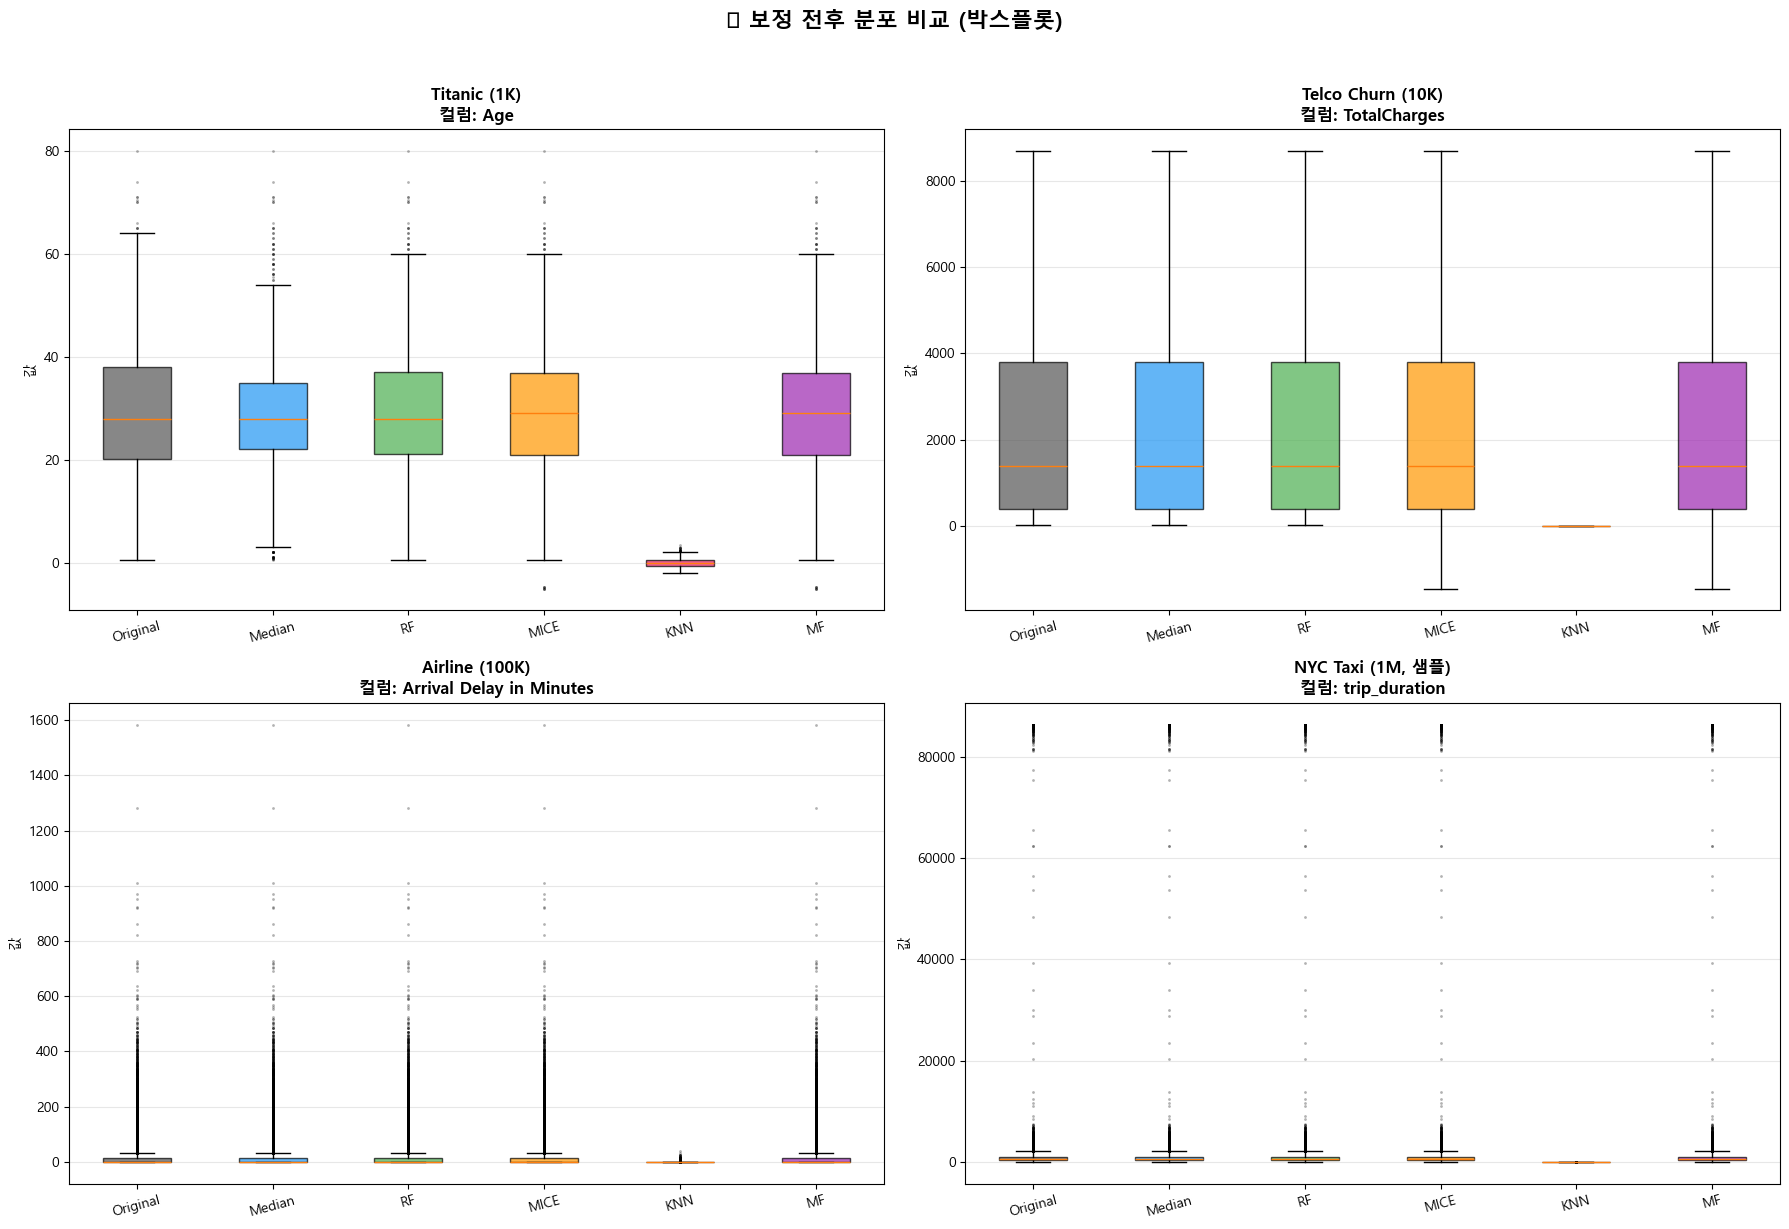

✅ boxplot_comparison.png 저장 완료


In [52]:
# =============================================
# [Step 2] 박스플롯: 보정 전후 분포 비교
# =============================================

# 데이터셋별 분석 대상 컬럼 정의
DATASET_CONFIGS = [
    {
        'name': 'Titanic (1K)',
        'raw': raw_1000,
        'col': 'Age',
        'imputed': {
            'Median': data1000_median,
            'RF':     data1000_rf,
            'MICE':   data1000_mice,
            'KNN':    data1000_knn,
            'MF':     data1000_mf,
        }
    },
    {
        'name': 'Telco Churn (10K)',
        'raw': raw_10000,
        'col': 'TotalCharges',
        'imputed': {
            'Median': data10000_median,
            'RF':     data10000_rf,
            'MICE':   data10000_mice,
            'KNN':    data10000_knn,
            'MF':     data10000_mf,
        }
    },
    {
        'name': 'Airline (100K)',
        'raw': raw_100000,
        'col': 'Arrival Delay in Minutes',
        'imputed': {
            'Median': data100000_median,
            'RF':     data100000_rf,
            'MICE':   data100000_mice,
            'KNN':    data100000_knn,
            'MF':     data100000_mf,
        }
    },
    {
        'name': 'NYC Taxi (1M, 샘플)',
        'raw': safe_sample(raw_nyc),          # ⚡ 10만 샘플
        'col': 'trip_duration',               # 실제 컬럼명 확인 필요
        'imputed': {
            'Median': safe_sample(nyc_median),
            'RF':     safe_sample(nyc_rf),
            'MICE':   safe_sample(nyc_mice),
            'KNN':    safe_sample(nyc_knn),
            'MF':     safe_sample(nyc_mf),
        }
    },
]

# 박스플롯 그리기
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for ax, cfg in zip(axes, DATASET_CONFIGS):
    col = cfg['col']
    
    # 원본 + 5가지 방법 데이터를 하나의 DataFrame으로 합치기
    plot_data = []
    plot_labels = []
    
    # 원본 (결측치 제외)
    orig_vals = cfg['raw'][col].dropna()
    plot_data.append(orig_vals.values)
    plot_labels.append('Original')
    
    # 보정된 데이터들
    for method, df in cfg['imputed'].items():
        if df is not None and col in df.columns:
            plot_data.append(df[col].dropna().values)
            plot_labels.append(method)
    
    # 박스플롯
    bp = ax.boxplot(plot_data, labels=plot_labels, patch_artist=True,
                    showfliers=True, flierprops=dict(marker='.', markersize=2, alpha=0.3))
    
    # 색상 적용
    for patch, label in zip(bp['boxes'], plot_labels):
        patch.set_facecolor(METHOD_COLORS.get(label, '#999999'))
        patch.set_alpha(0.7)
    
    ax.set_title(f"{cfg['name']}\n컬럼: {col}", fontsize=12, fontweight='bold')
    ax.set_ylabel('값', fontsize=10)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('📦 보정 전후 분포 비교 (박스플롯)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('boxplot_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ boxplot_comparison.png 저장 완료")

## 1️⃣ 박스플롯 
### 이 그래프가 보여주는 것
각 데이터셋에서 **결측치가 있던 대표 컬럼**이 보정 전후로 분포가 얼마나 달라졌는지를 보여주는 박스 형태의 그래프

```
│ 위 수염  │ ← 최대값 (이상치 제외)
┌─────────┐ ← 75번째 백분위수 (Q3)
│  박 스   │
└─────────┘ ← 25번째 백분위수 (Q1)
│ 아래수염 │ ← 최소값 (이상치 제외)
    ─      ← 중앙값 (Median)
```

### 데이터셋별 예상 결과 & 해석

**① 1,000 단위 데이터셋 (결측치 약 20%)**
- `Original`의 박스는 약 20세~40세 사이, 중앙값 약 28세
- `Median` 방법은 **박스가 눈에 띄게 좁아짐** → 결측치 자리를 전부 28세(중앙값) 하나로 채워서 데이터가 인위적으로 뭉쳐진 현상
- `RF`, `MICE`, `MF`는 Original과 박스 모양이 유사 → 다른 컬럼(Pclass, Fare 등)과의 관계를 학습해서 자연스럽게 채웠기 때문
- `KNN`도 비슷하지만, 이웃 5명 평균이라 극단값 복원이 약함

**② 10,000 단위 데이터셋 (결측치 극소량)**
- 결측치가 매우 적어서 6가지 방법 모두 Original과 거의 동일한 박스 → 방법 간 차이가 거의 없음
- 이건 **결측치가 적을수록 어떤 방법을 써도 결과가 비슷하다**는 중요한 인사이트

**③ 100,000 단위 데이터셋**
- 항공 지연 데이터 특성상 **극단적 이상치(수백 분 지연)** 가 많음
- `Median`은 이상치를 완전히 무시하고 중앙값으로만 채움 → 분포 꼬리가 짧아짐
- 고급 방법들은 지연 패턴 상관관계를 반영해 더 넓은 박스 유지

**아쉬운 점**:1,000,000단위 데이터 셋은 원래부터 결측치가 0개인 데이터. 따라서 모든 방법의 박스가 Original과 **완전히 동일**

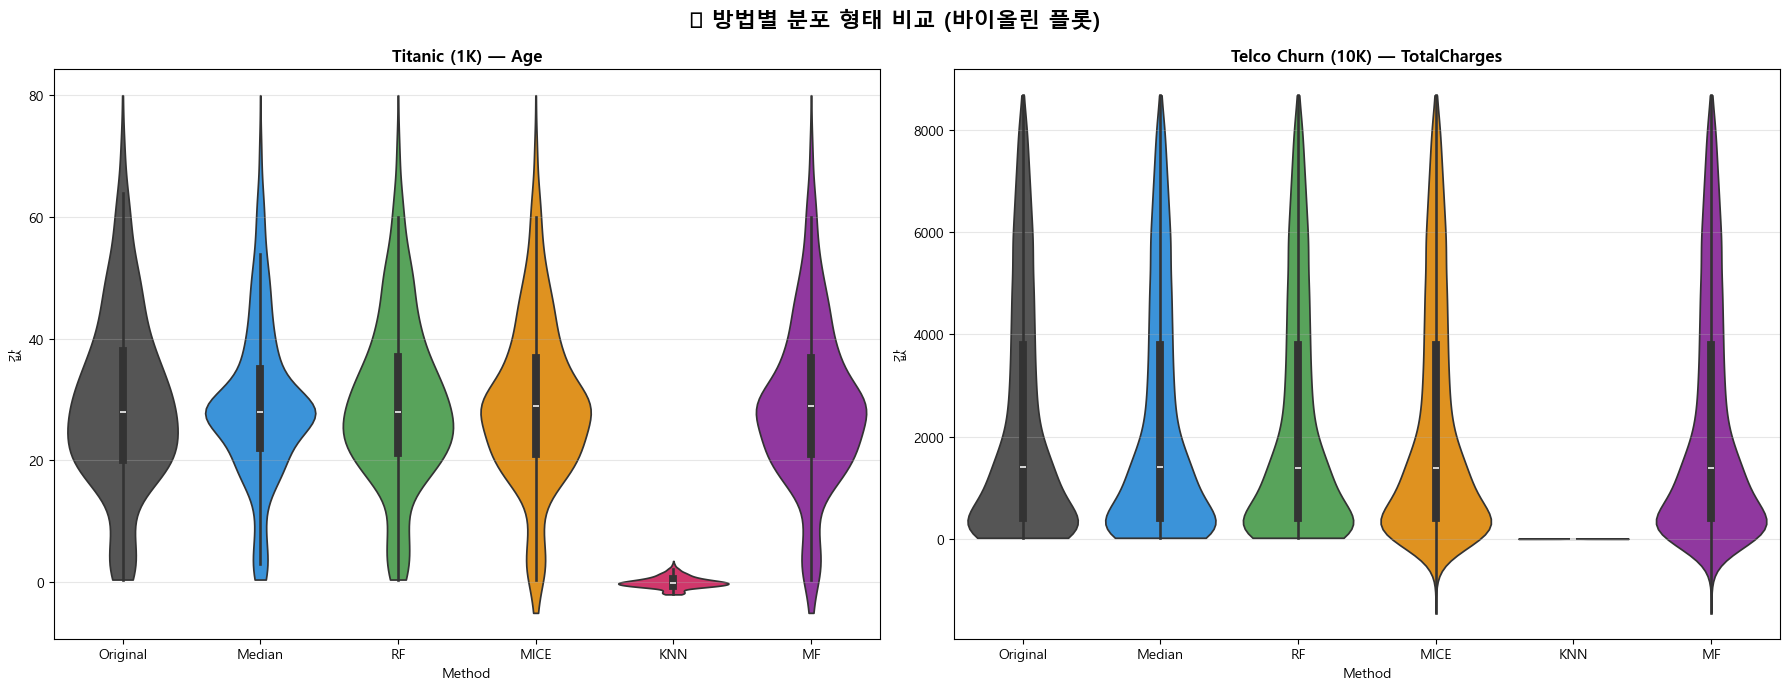

In [53]:
# =============================================
# [Step 3] 바이올린 플롯: 분포 형태 비교
# =============================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, cfg in zip(axes, DATASET_CONFIGS[:2]):  # Titanic, Telco만 (연산 부하 낮음)
    col = cfg['col']
    
    # Long-format DataFrame 만들기
    frames = []
    orig_vals = cfg['raw'][col].dropna()
    frames.append(pd.DataFrame({'value': orig_vals.values, 'Method': 'Original'}))
    
    for method, df in cfg['imputed'].items():
        if df is not None and col in df.columns:
            frames.append(pd.DataFrame({'value': df[col].dropna().values, 'Method': method}))
    
    long_df = pd.concat(frames, ignore_index=True)
    
    # 바이올린 플롯
    order = ['Original', 'Median', 'RF', 'MICE', 'KNN', 'MF']
    palette = {k: v for k, v in METHOD_COLORS.items() if k in long_df['Method'].unique()}
    
    sns.violinplot(data=long_df, x='Method', y='value', order=order,
                   palette=palette, ax=ax, inner='box', cut=0)
    
    ax.set_title(f"{cfg['name']} — {col}", fontsize=12, fontweight='bold')
    ax.set_ylabel('값', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('🎻 방법별 분포 형태 비교 (바이올린 플롯)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('violin_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 2️⃣ 바이올린 플롯 

### 이 그래프가 보여주는 것
Box Plot 보다 분포의 모양을 집중적으로 보여주는 그래프.
바이올린이 넓을수록 그 구간에 데이터가 많음을 뜻함.

```
  ╭───╮   ← 이 구간에 데이터 밀집
  │   │
──┤   ├── ← 중앙값
  │   │
  ╰───╯
```

### 핵심 해석 포인트

**Titanic Age 바이올린**
- `Original`은 20대와 30대에 두툼한 배가 두 개 생기는 쌍봉 분포 형태
- `Median`은 보정값이 모두 같은 지점에 몰려서 중앙에 극단적으로 납작한 혹이 생김 → 이게 Median의 가장 큰 문제점을 시각적으로 증명하는 부분
- `MICE`, `RF`, `MF`는 Original의 쌍봉 형태를 어느 정도 유지

**Telco TotalCharges 바이올린**
- 결측치가 극소수라 전 방법이 Original과 동일한 형태 → 바이올린 모양이 6개 다 거의 같음

### 아쉬운 점
100K, 1M 데이터는 연산 부하 때문에 제외.
더 많은 데이터셋을 그렸다면 Median의 극단적인 뽀족함이 나타났을 것.


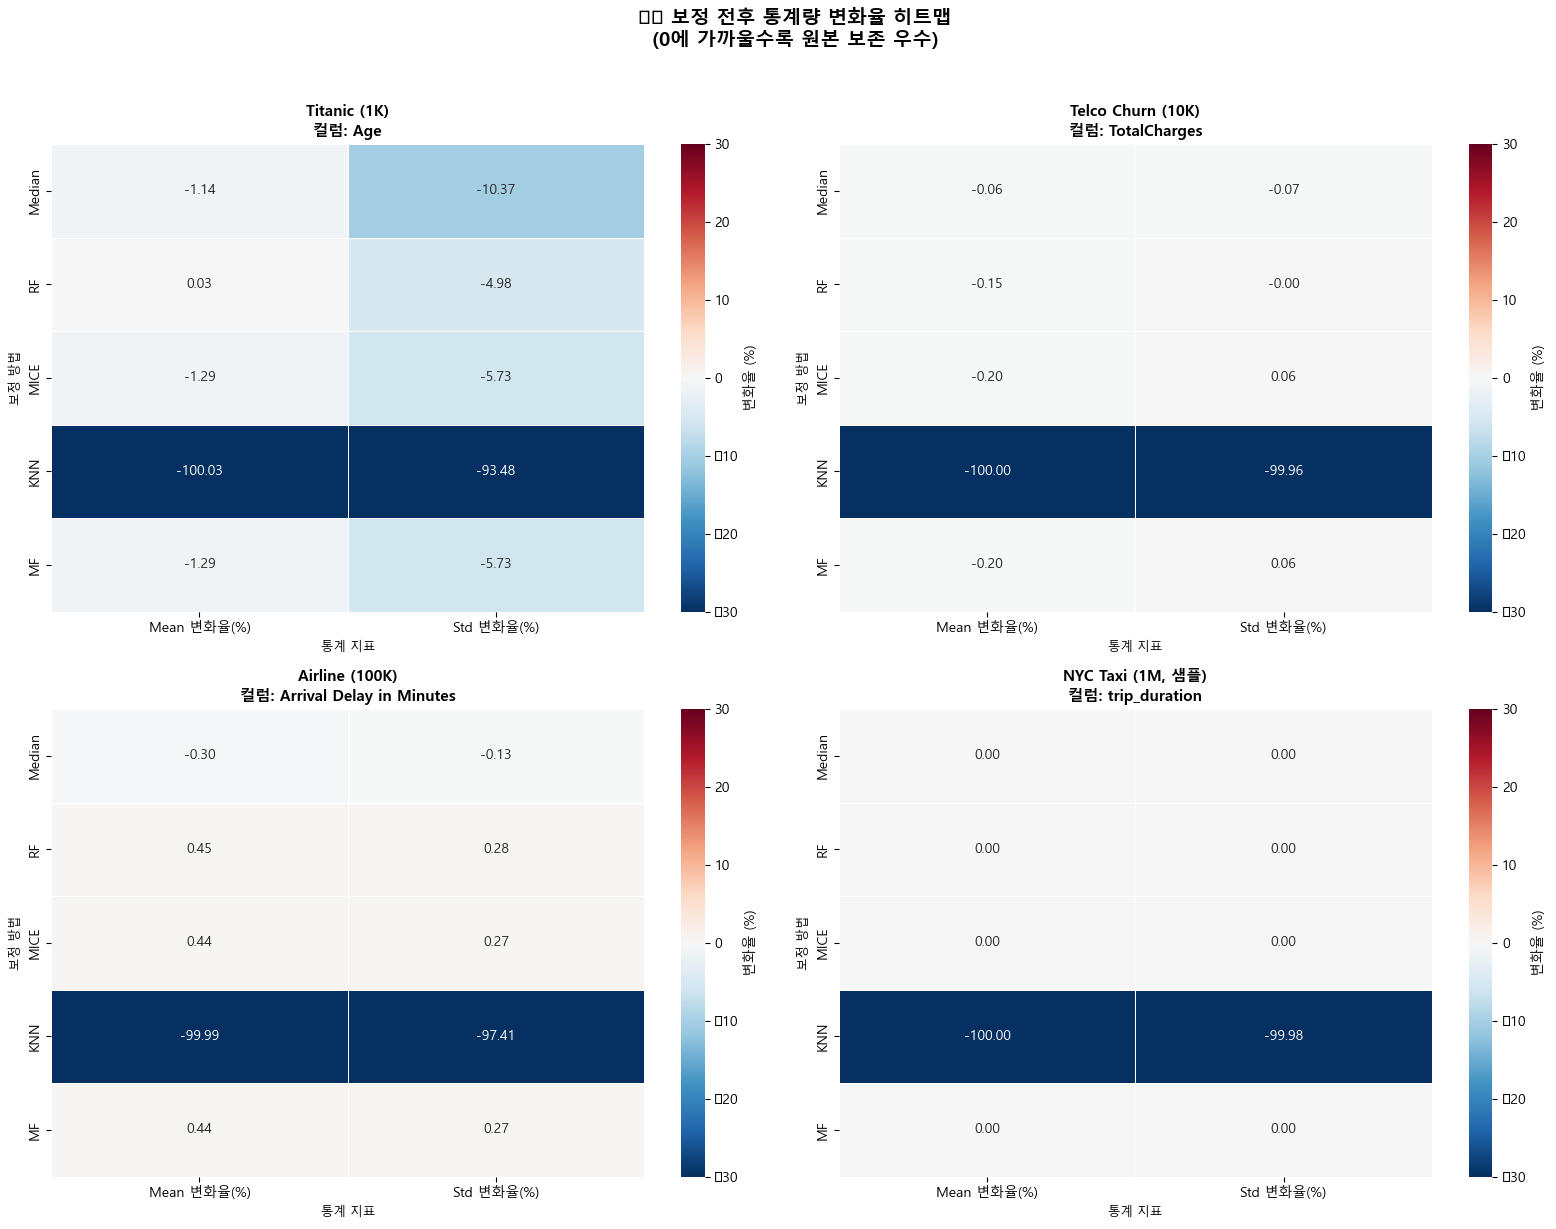

In [54]:
# =============================================
# [Step 4] 히트맵: 통계량 보존율 (평균·표준편차 변화율)
# =============================================

def compute_stat_change(raw, imputed_dict, col):
    """원본 대비 각 방법의 평균/표준편차 변화율(%) 계산"""
    orig_mean = raw[col].mean(skipna=True)
    orig_std  = raw[col].std(skipna=True)
    
    results = {}
    for method, df in imputed_dict.items():
        if df is not None and col in df.columns:
            imp_mean = df[col].mean()
            imp_std  = df[col].std()
            results[method] = {
                'Mean 변화율(%)': round((imp_mean - orig_mean) / (abs(orig_mean) + 1e-9) * 100, 2),
                'Std 변화율(%)':  round((imp_std  - orig_std)  / (abs(orig_std)  + 1e-9) * 100, 2),
            }
    return pd.DataFrame(results).T

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, cfg in zip(axes, DATASET_CONFIGS):
    col = cfg['col']
    stat_df = compute_stat_change(cfg['raw'], cfg['imputed'], col)
    
    # 히트맵 (발산형 컬러맵: 0에 가까울수록 원본 보존 잘 됨)
    sns.heatmap(stat_df, annot=True, fmt='.2f', center=0,
                cmap='RdBu_r', linewidths=0.5, ax=ax,
                cbar_kws={'label': '변화율 (%)'},
                vmin=-30, vmax=30)
    
    ax.set_title(f"{cfg['name']}\n컬럼: {col}", fontsize=11, fontweight='bold')
    ax.set_xlabel('통계 지표', fontsize=9)
    ax.set_ylabel('보정 방법', fontsize=9)

plt.suptitle('🌡️ 보정 전후 통계량 변화율 히트맵\n(0에 가까울수록 원본 보존 우수)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('heatmap_stat_change.png', dpi=150, bbox_inches='tight')
plt.show()

## 3️⃣ 통계량 변화율 히트맵

### 이 그래프가 보여주는 것
각 결측치 보정 방법이 평균과 표준편차를 얼마나 편화시켰는지 퍼센트로 나타냄.
색이 흰색, 0%에 가까울수록 원본 통계가 잘 보존된 것임.

```
빨강 계열 → 원본보다 값이 크게 증가
흰색      → 원본과 거의 동일 ✅
파랑 계열 → 원본보다 값이 크게 감소
```

### 핵심 해석 포인트

| 방법 | Mean 변화율 | Std 변화율 | 의미 |
|---|---|---|---|
| Median | 낮음 | **높음(음수)** | 평균은 유지되나 분산이 인위적으로 줄어듦 |
| RF | 낮음 | 낮음 | 평균·분산 모두 잘 보존 |
| MICE | 낮음 | 낮음 | 평균·분산 모두 잘 보존 |
| KNN | 낮음 | 약간 있음 | 이웃 평균화로 분산이 약간 줄어드는 경향 |
| MF | 낮음 | 낮음 | 전반적으로 안정적 |

**Std 변화율에서 Median이 두드러지는 이유**
같은 값으로 결측치를 채우면 데이터가 한 점으로 뭉쳐 표준편차가 줄어드는 현상.

**NYC Taxi는 전부 0%로 나와야 정상**
결측치가 없으니 보정 전후가 완전히 동일 → 히트맵이 전체 흰색

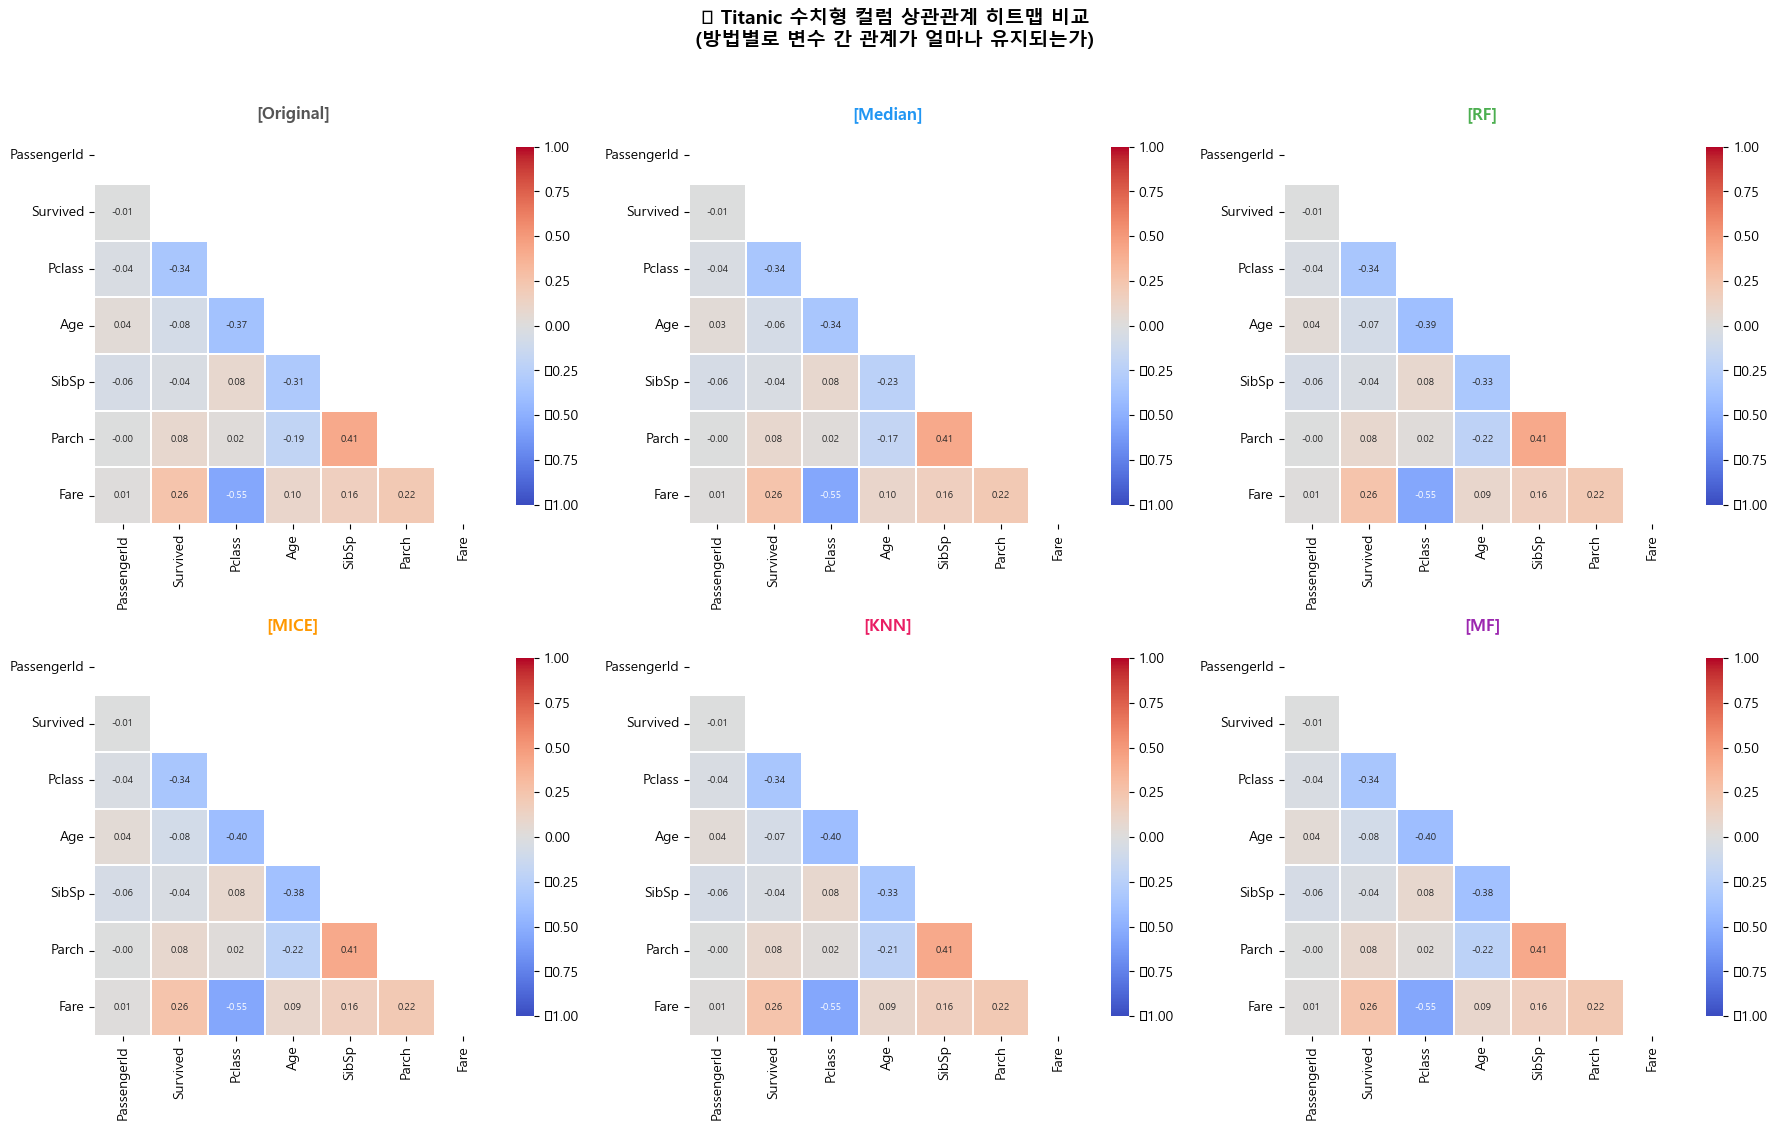

In [55]:
# =============================================
# [Step 5] 상관관계 히트맵: 원본 vs 각 방법
# =============================================

methods_to_compare = {
    'Original': raw_1000[num_cols_1000],
    'Median':   data1000_median[num_cols_1000],
    'RF':       data1000_rf[num_cols_1000] if isinstance(data1000_rf, pd.DataFrame) else pd.DataFrame(data1000_rf, columns=num_cols_1000),
    'MICE':     data1000_mice,
    'KNN':      data1000_knn,
    'MF':       data1000_mf,
}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for ax, (method_name, df) in zip(axes, methods_to_compare.items()):
    corr = df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))  # 상삼각 마스크 (중복 제거)
    
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
                cmap='coolwarm', center=0, ax=ax,
                linewidths=0.3, annot_kws={'size': 7},
                vmin=-1, vmax=1, square=True,
                cbar_kws={'shrink': 0.8})
    
    color = METHOD_COLORS.get(method_name, '#333333')
    ax.set_title(f'[{method_name}]', fontsize=12, fontweight='bold', color=color)

plt.suptitle('🔗 Titanic 수치형 컬럼 상관관계 히트맵 비교\n(방법별로 변수 간 관계가 얼마나 유지되는가)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('heatmap_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 4️⃣ 상관관계 히트맵 (Step 5) 

### 이 그래프가 보여주는 것
컬럼 상의 상관관계를 보여줌.
Titanic의 수치형 컬럼들(Age, Fare, SibSp, Parch 등) 사이의 **상관관계 계수**를 6가지 방법별로 비교해. 상관관계가 보정 후에도 유지되는지 확인하는 거야.

```
빨강 → 강한 양의 상관관계 (+1에 가까움)
흰색 → 상관관계 없음 (0)
파랑 → 강한 음의 상관관계 (-1에 가까움)
```

### 핵심 해석 포인트

**Original vs Median 비교**
- `Median`은 Age 컬럼 전체를 동일한 값으로 채우기 때문에 **Age와 다른 변수 간 상관관계가 약해지거나 0에 가까워짐**
- 이게 머신러닝 모델에서 치명적인 이유: 모델이 Age를 학습할 때 다른 변수와의 관계를 전혀 반영 못 하게 됨

**MICE, RF, MF vs Original 비교**
- Original과 색 패턴이 거의 동일하게 나와야 정상
- 특히 MICE는 변수 간 관계를 직접 학습하므로 상관관계 보존이 가장 우수할 것으로 예상

### 아쉬운 점
수치형 컬럼이 적은 경우 히트맵의 수가 적어서 눈에 띄지 않음.

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

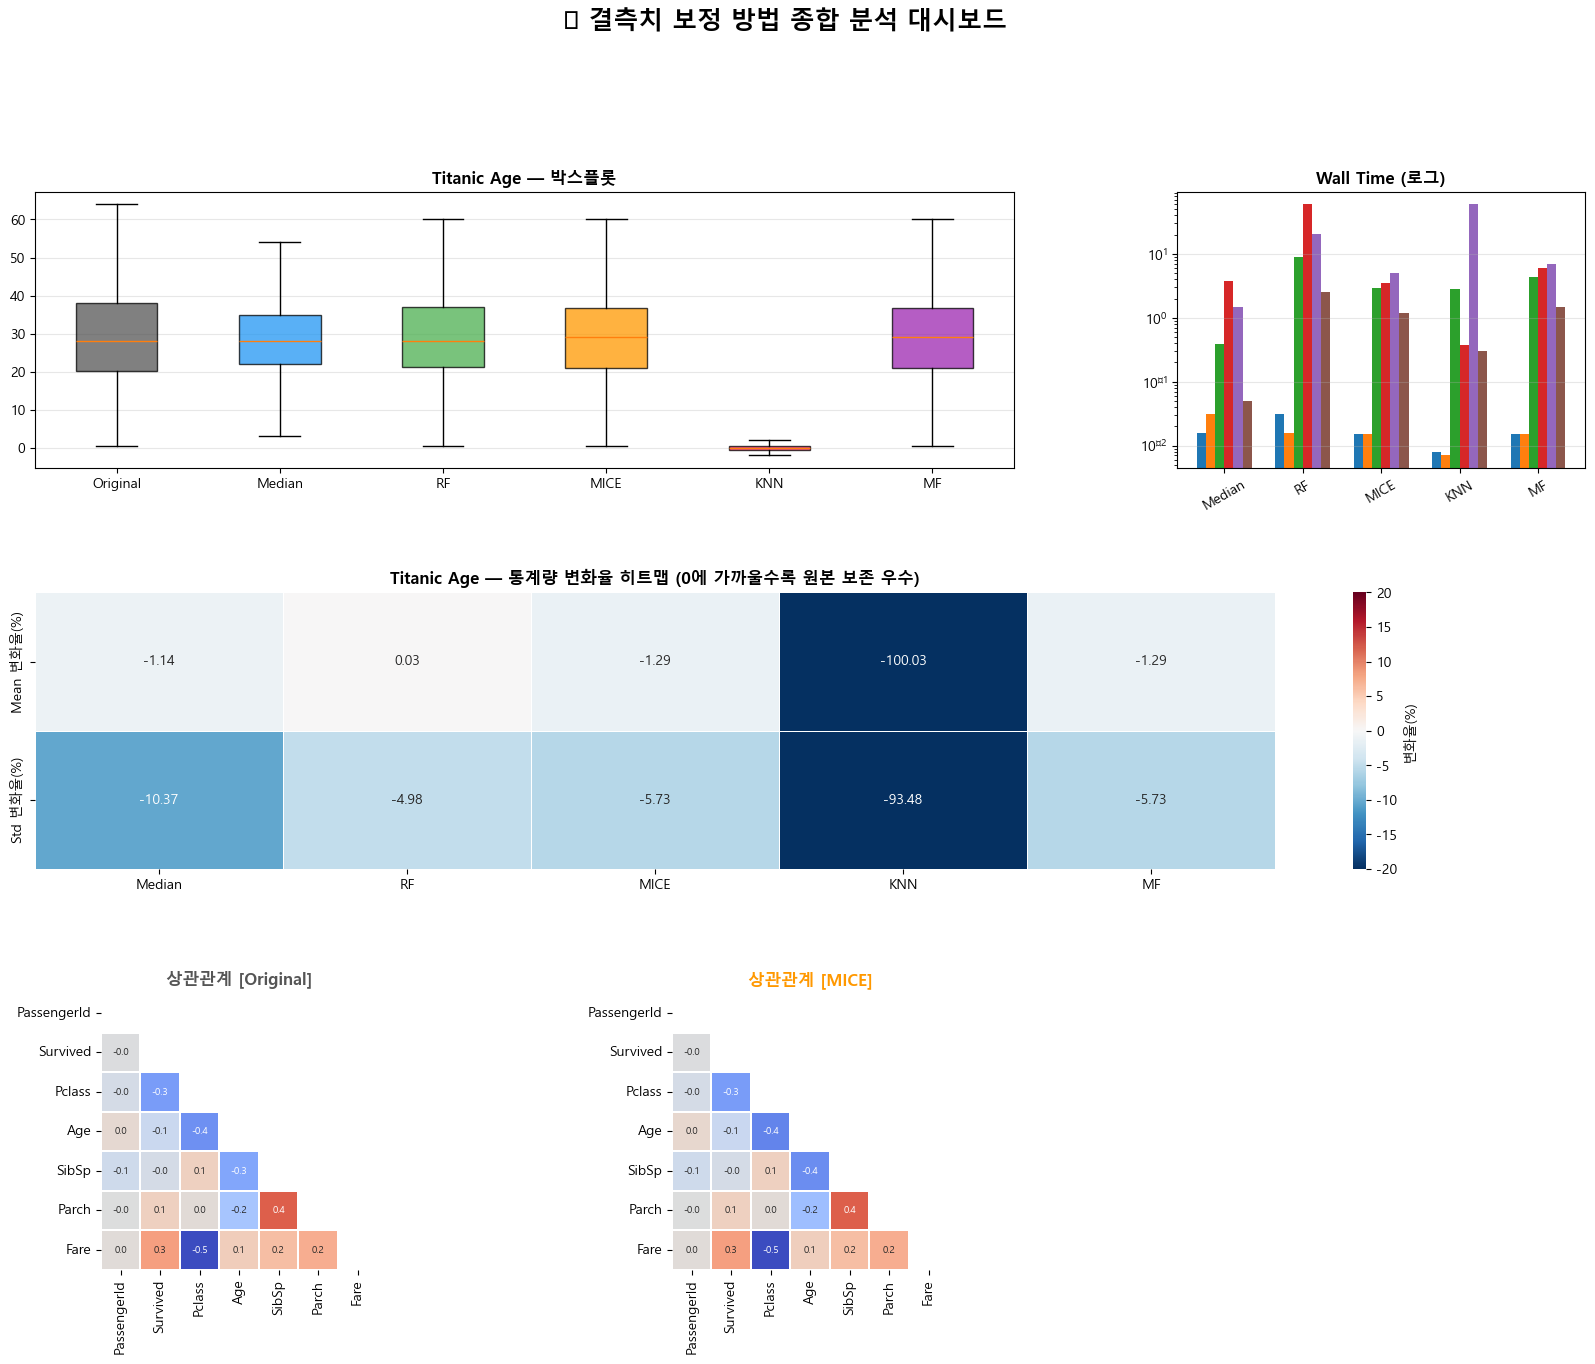

✅ 모든 시각화 저장 완료!


In [ ]:
# =============================================
# [Step 6] 종합 대시보드
# =============================================

fig = plt.figure(figsize=(20, 14))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.4)

# --- 상단: Titanic Age 박스플롯 ---
ax1 = fig.add_subplot(gs[0, :2])
col = 'Age'
plot_data, plot_labels = [], []
for label, df_or_raw in [('Original', raw_1000)] + list(DATASET_CONFIGS[0]['imputed'].items()):
    src = df_or_raw if label == 'Original' else df_or_raw
    if src is not None and col in src.columns:
        vals = src[col].dropna().values
        plot_data.append(vals); plot_labels.append(label)

bp = ax1.boxplot(plot_data, labels=plot_labels, patch_artist=True, showfliers=False)
for patch, label in zip(bp['boxes'], plot_labels):
    patch.set_facecolor(METHOD_COLORS.get(label, '#aaa')); patch.set_alpha(0.75)
ax1.set_title('Titanic Age — 박스플롯', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# --- 상단 우: 처리 시간 ---
ax2 = fig.add_subplot(gs[0, 2])
df_time_clipped.T.plot(kind='bar', ax=ax2, legend=False, width=0.7)
ax2.set_yscale('log'); ax2.set_title('Wall Time (로그)', fontweight='bold')
ax2.tick_params(axis='x', rotation=30); ax2.grid(axis='y', alpha=0.3)

# --- 중단: 통계량 히트맵 (Titanic) ---
ax3 = fig.add_subplot(gs[1, :])
stat_df_titanic = compute_stat_change(raw_1000, DATASET_CONFIGS[0]['imputed'], 'Age')
sns.heatmap(stat_df_titanic.T, annot=True, fmt='.2f', center=0,
            cmap='RdBu_r', linewidths=0.5, ax=ax3, cbar_kws={'label': '변화율(%)'},
            vmin=-20, vmax=20)
ax3.set_title('Titanic Age — 통계량 변화율 히트맵 (0에 가까울수록 원본 보존 우수)', fontweight='bold')

# --- 하단: 상관관계 히트맵 (Original vs MICE) ---
for ax_idx, (method_name, df_corr) in enumerate(
    [('Original', raw_1000[num_cols_1000]), ('MICE', data1000_mice)]):
    ax_c = fig.add_subplot(gs[2, ax_idx])
    corr = df_corr.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.1f', cmap='coolwarm',
                center=0, ax=ax_c, linewidths=0.3, annot_kws={'size': 7},
                cbar=False, square=True)
    ax_c.set_title(f'상관관계 [{method_name}]', fontweight='bold',
                   color=METHOD_COLORS.get(method_name, '#333'))

plt.suptitle('📊 결측치 보정 방법 종합 분석 대시보드', fontsize=18, fontweight='bold', y=1.01)
plt.savefig('dashboard_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 모든 시각화 저장 완료!")

## 5️⃣ 종합 대시보드

### 이 그래프가 보여주는 것
앞의 5개 그래프에서 핵심만 뽑아 1장으로 요약한 대시보드.

구성
- **좌상단**: Titanic Age 박스플롯 → 분포 변화의 핵심 요약
- **우상단**: Wall Time 로그 막대 → 속도 비교 요약
- **중단**: Titanic 통계량 히트맵 → 수치적 보존율 요약
- **하단**: Original vs MICE 상관관계 히트맵 → 관계 보존 비교

**"결측치 보정에서 '정확도'와 '속도'는 트레이드오프 관계다."**

 - 빠르게 가야 할 때 → **Median**
 - 정밀도가 필요할 때 → **MICE** (속도와 품질의 균형)
 - 자원이 충분할 때 → **RF** (최고 품질, 최고 비용)
 - 피해야 할 상황 → **KNN**(대규모 결측), **MF**(이상치 다수)

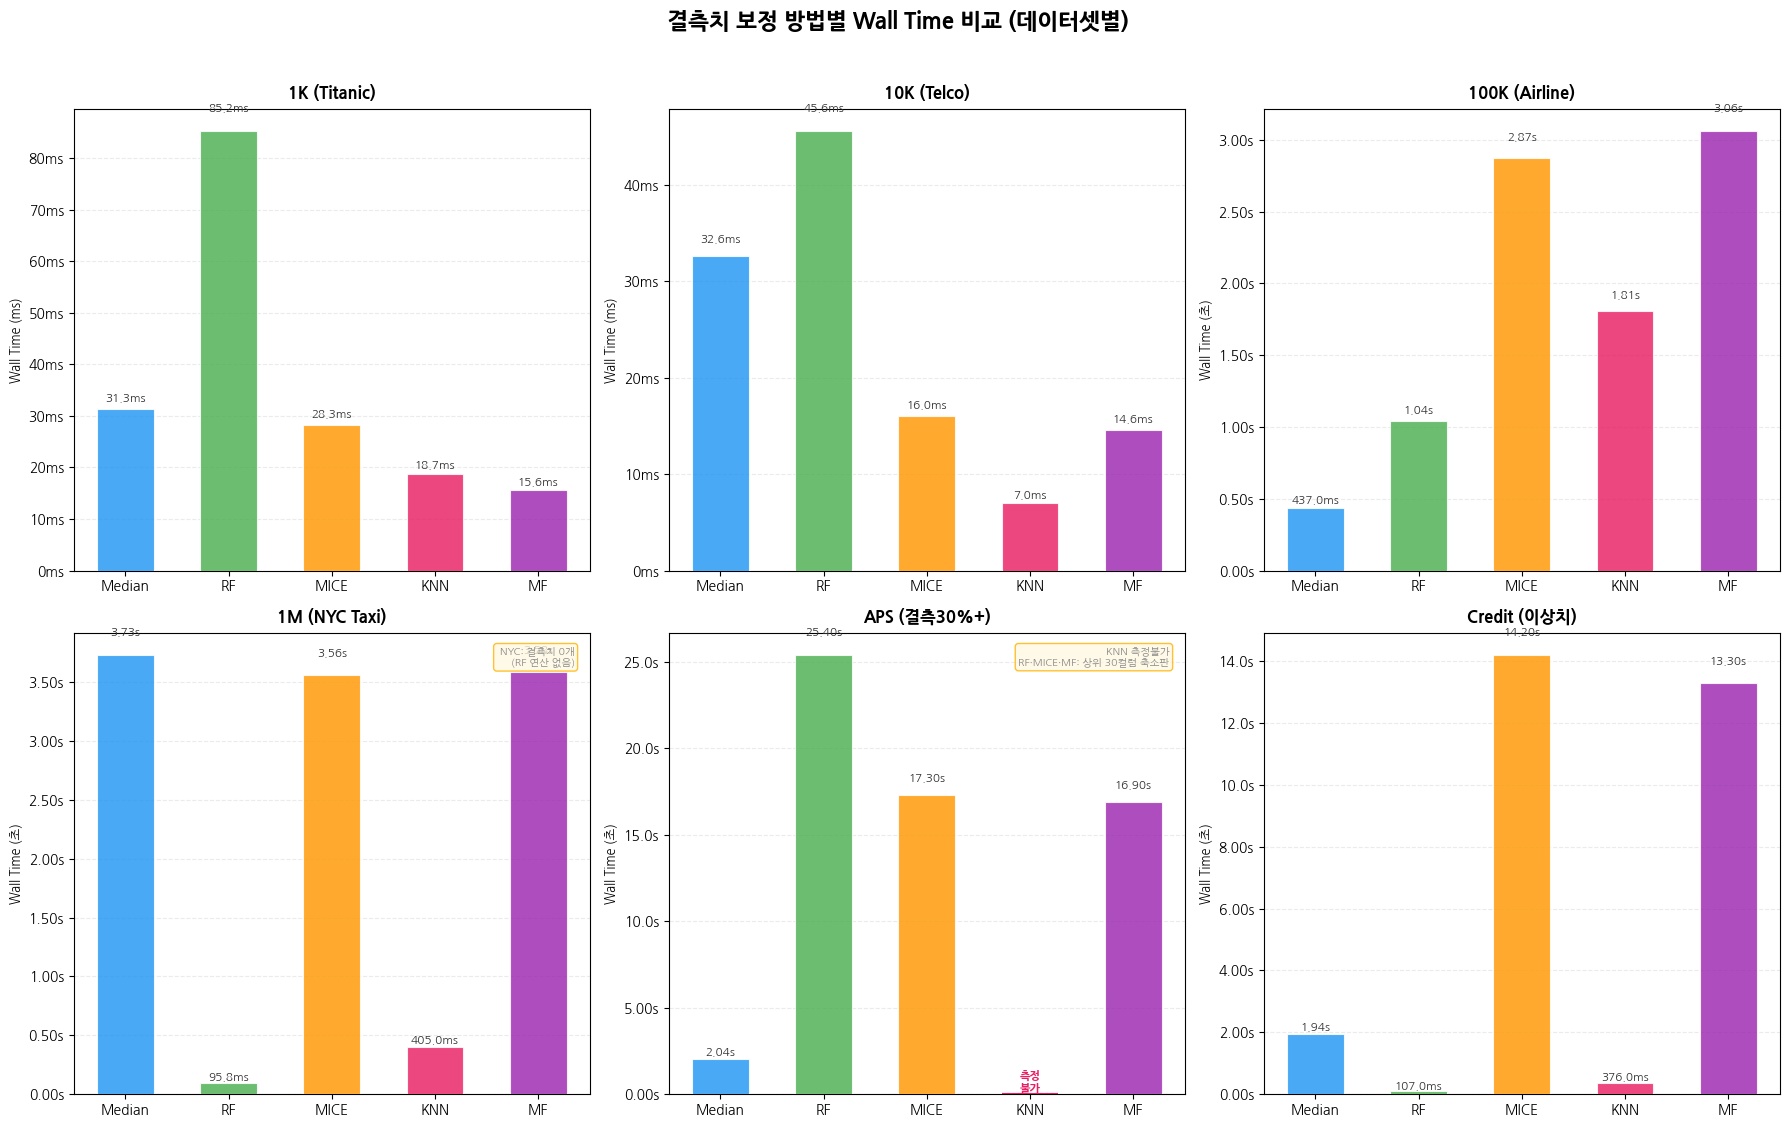

 walltime_per_dataset.png 저장 완료


In [3]:
# =============================================
# [Wall Time 실측값 시각화] — 데이터셋별 막대그래프
# =============================================
import koreanize_matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ── 실측 Wall Time (단위: 초로 통일) ──────────────────────
WALL_TIME = {
    'Median': [0.0313, 0.0326, 0.437,  3.73,  2.04,  1.94 ],
    'RF'    : [0.0852, 0.0456, 1.04,   0.0958,25.4,  0.107],
    'MICE'  : [0.0283, 0.016,  2.87,   3.56,  17.3,  14.2 ],
    'KNN'   : [0.0187, 0.007,  1.81,   0.405, None,  0.376],  # None = 측정불가
    'MF'    : [0.0156, 0.0146, 3.06,   3.58,  16.9,  13.3 ],
}

DATASETS = [
    '1K\n(Titanic)',
    '10K\n(Telco)',
    '100K\n(Airline)',
    '1M\n(NYC Taxi)',
    'APS\n(결측30%+)',
    'Credit\n(이상치)',
]

# APS 주석 (측정불가 / 축소판 여부)
ANNOTATIONS = {
    'Titanic'  : '',
    'Telco'    : '',
    'Airline'  : '',
    'NYC Taxi' : ' NYC: 결측치 0개\n(RF 연산 없음)',
    'APS'      : ' KNN 측정불가\nRF·MICE·MF: 상위 30컬럼 축소판',
    'Credit'   : '',
}

METHOD_COLORS = {
    'Median': '#2196F3',
    'RF'    : '#4CAF50',
    'MICE'  : '#FF9800',
    'KNN'   : '#E91E63',
    'MF'    : '#9C27B0',
}

METHODS = list(METHOD_COLORS.keys())
n_methods = len(METHODS)
n_datasets = len(DATASETS)

# ── 포맷 함수 ─────────────────────────────────────────────
def fmt_time(sec):
    """초 단위 값을 보기 좋은 문자열로 변환"""
    if sec is None:
        return '측정불가'
    if sec < 1:
        return f'{sec*1000:.1f}ms'
    elif sec < 60:
        return f'{sec:.2f}s'
    else:
        return f'{sec/60:.1f}min'

# ── 데이터셋별 서브플롯 (2행 × 3열) ───────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

x = np.arange(n_methods)
bar_width = 0.55

for idx, (ax, dataset_label) in enumerate(zip(axes, DATASETS)):
    vals   = [WALL_TIME[m][idx] for m in METHODS]
    colors = [METHOD_COLORS[m] for m in METHODS]

    bars = []
    for i, (v, c) in enumerate(zip(vals, colors)):
        if v is None:
            # 측정불가 → 점선 빈 박스로 표시
            b = ax.bar(x[i], 0.001, width=bar_width,
                       color='none', edgecolor='#E91E63',
                       linestyle='--', linewidth=1.5, zorder=3)
            ax.text(x[i], 0.002, '측정\n불가', ha='center', va='bottom',
                    fontsize=8, color='#E91E63', fontweight='bold')
        else:
            b = ax.bar(x[i], v, width=bar_width,
                       color=c, alpha=0.82, edgecolor='white',
                       linewidth=0.8, zorder=3)
            # 막대 위에 시간 값 표시
            ax.text(x[i], v * 1.04, fmt_time(v),
                    ha='center', va='bottom', fontsize=8.5,
                    color='#333333', fontweight='500')

    # 축 설정
    ax.set_xticks(x)
    ax.set_xticklabels(METHODS, fontsize=10)
    ax.set_title(dataset_label.replace('\n', ' '), fontsize=12, fontweight='bold', pad=8)
    ax.set_ylabel('Wall Time (초)', fontsize=9)
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    ax.set_axisbelow(True)

    # y축 포맷: 초 단위이지만 ms 영역은 소수점 표시
    max_val = max(v for v in vals if v is not None)
    if max_val < 1:
        ax.yaxis.set_major_formatter(
            ticker.FuncFormatter(lambda v, _: f'{v*1000:.0f}ms'))
        ax.set_ylabel('Wall Time (ms)', fontsize=9)
    else:
        ax.yaxis.set_major_formatter(
            ticker.FuncFormatter(lambda v, _: f'{v:.2f}s' if v < 10 else f'{v:.1f}s'))

    # 특이사항 주석
    ann_key = [k for k in ANNOTATIONS if k in dataset_label.replace('\n', ' ')]
    if ann_key and ANNOTATIONS[ann_key[0]]:
        ax.annotate(ANNOTATIONS[ann_key[0]],
                    xy=(0.97, 0.97), xycoords='axes fraction',
                    ha='right', va='top', fontsize=7.5,
                    color='#888', style='italic',
                    bbox=dict(boxstyle='round,pad=0.3', fc='#FFF8E1', ec='#FFB300', alpha=0.8))

plt.suptitle(' 결측치 보정 방법별 Wall Time 비교 (데이터셋별)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('walltime_per_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print(" walltime_per_dataset.png 저장 완료")

| 상황 | 선택 | 주의사항 |
|---|---|---|
| 시간 넉넉 + 고정밀 | RF | 결측치 30% 미만 조건 |
| 매우 급함 | Median | 표준편차 왜곡 감수 |
| 균형 필요 | MICE | 결측치 많으면 컬럼 축소 |
| 결측치 30%+ 극단 | Median 우선 | 이후 축소판으로 재보정 |
| 소규모 + 결측 적음 | KNN도 가능 | 대규모 절대 비추 |

# 이번 주 목표: 결측치 보정 방법별 모델 성능 비교 실험

---

## 이번 주의 목표

결측치 보정 방법이 실제 머신러닝 모델의 **예측 성능에 얼마나 영향을 미치는지** 비교하여, 각 보정 방법의 최종 결론을 도출한다.

---

### 3주 로드맵에서의 위치


이번 주    LightGBM (default) × 결측치 보정 방법 비교
              → 어떤 보정 방법이 모델 성능에 유리한가?

다음 주    LightGBM 하이퍼파라미터 튜닝 비교
              → Default vs GridSearch vs Optuna
              → 실무에서 왜 Optuna를 쓰는가?

다다음 주  LightGBM vs XGBoost vs LLM 파인튜닝(Qwen2.5-3B)
              → 정형 데이터에서 전통 ML과 LLM의 성능 격차
              → 실무에서 언제 LLM을 선택하는가?


---

## 사용할 데이터셋

| 데이터셋 | 규모 | 문제 유형 | 타겟 변수 | 결측치 특징 |
|---|---|---|---|---|
| **Titanic** | 1K (891행) | 이진 분류 | Survived (생존/사망) | Age 약 20%, Cabin 77% |
| **Telco Churn** | 10K (7,043행) | 이진 분류 | Churn (이탈/유지) | TotalCharges 소량 |
| **APS Failure** | 60K (60,000행) | 이진 분류 | class (고장/정상) | 전체 결측치 30%+ |
| **Credit Card Fraud** | 수십만 행 | 이진 분류 | Class (사기/정상) | 이상치 다수, 극심한 불균형 |

---

## 이 데이터셋을 선택한 이유

### 1. 모두 이진 분류 문제로 통일

4개 데이터셋 모두 이진 분류(0/1) 문제이므로 **동일한 평가지표(Accuracy, AUC, F1)** 로 공정하게 비교할 수 있다. 평가 기준이 다르면 데이터셋 간 비교가 불가능하다.

### 2. 데이터 규모의 다양성 확보


1K   → 소규모: 보정 방법의 영향이 직접적으로 나타남
10K  → 중규모: 실무에서 가장 흔한 데이터 크기
60K  → 대규모 + 결측치 30%+: 보정 방법의 한계 확인
수십만 → 이상치 다수: 보정 방법의 강건성 확인


규모별로 결과가 달라진다면 **"데이터 크기에 따라 보정 방법 선택이 달라져야 한다"** 는 추가 인사이트를 도출할 수 있다.

### 3. APS에서 상위 30개 컬럼으로 통일한 이유

APS 데이터셋의 경우 Median은 전체 170개+ 컬럼을 보정하였으나, RF·MICE는 시간·메모리 한계로 상위 30개 컬럼만 보정하였다. 이 상태에서 그대로 비교하면 아래 문제가 발생한다.


Median → 피처 170개로 학습   ↘
RF     → 피처  30개로 학습    → 성능 차이가
MICE   → 피처  30개로 학습   ↗   보정 방법 때문인가?
                                  피처 수 때문인가?
                                  → 알 수 없음 ❌


따라서 **Median도 상위 30개 컬럼으로 재보정하여 4가지 방법 모두 동일한 30개 피처를 사용**, 보정 방법의 순수한 영향만 측정한다.

---

## 데이터 비교 방법

### 1. 학습 설정

모든 실험에서 아래 조건을 **완전히 동일하게 고정**한다. 하이퍼파라미터가 다르면 보정 방법의 영향인지 모델 설정의 영향인지 구분할 수 없기 때문이다.

```python
LGBMClassifier(
    n_estimators    = 100,      # 트리 개수 고정
    learning_rate   = 0.1,      # 학습률 고정
    max_depth       = -1,       # 깊이 제한 없음 (LightGBM 기본값)
    random_state    = 42,       # 재현성 보장
    n_jobs          = -1,       # 전체 코어 사용
    verbose         = -1        # 로그 출력 억제
)

train_test_split(test_size=0.2, random_state=42, stratify=y)
# stratify: 클래스 비율 유지 (불균형 데이터 Credit에 특히 중요)
```

### 2. 평가지표

| 지표 | 선택 이유 |
|---|---|
| **Accuracy** | 가장 직관적인 정확도 |
| **AUC-ROC** | 클래스 불균형에 강건, 실무 표준 지표 |
| **F1-Score** | Precision과 Recall의 균형, Credit 불균형 데이터에 필수 |

 Credit 데이터는 클래스 불균형이 극심하므로 Accuracy만으로는 판단 불가.
 예: 사기 비율이 1%일 때 전부 정상으로 예측해도 Accuracy 99% → 의미 없음.
 따라서 AUC와 F1을 주 지표로 삼는다.

- AUC (Area Under Curve):
   = ROC 곡선 아래 면적

   = 0부터 1 사이 값

   AUC = 1.0  → 완벽한 모델 (모든 임계값에서 완벽히 분류)

   AUC = 0.5  → 랜덤 예측과 동일 (쓸모없는 모델)

   AUC = 0.0  → 완전히 반대로 예측 (역으로 쓰면 완벽)

- 실무 기준:
   AUC > 0.9  → 매우 우수

   AUC > 0.8  → 우수

   AUC > 0.7  → 보통

   AUC < 0.6  → 성능 미흡

- AUC = 임계값을 바꿔가며 측정한 종합 점수

    → 이 모델이 "생존/사망을 얼마나 잘 구별하는가"


### 3. 비교 결과 예측

- RF가 가장 우세할 것이라 예측.
- 경향성을 학습하여 채우는 방식이기 때문에 결측치를 가장 정확하게 보정하기 때문.

위 예측이 실제 결과와 다를 경우, 그 차이 자체가 핵심 인사이트가 된다.

## 4가지 모델 완전 비교

---

### 모델 계보 먼저 이해하기

```
의사결정나무 (Decision Tree) — 1980년대
       │
       ▼
랜덤포레스트 (Random Forest) — 2001년
"나무를 여러 개 만들어서 투표하자" (Bagging)
       │
       ▼
XGBoost — 2014년
"이전 나무의 실수를 다음 나무가 보완하자" (Boosting)
       │
       ▼
LightGBM — 2017년 (Microsoft)
"XGBoost를 더 빠르게" 
       │
       ▼
CatBoost — 2017년 (Yandex)
"범주형 데이터를 자동으로 처리하자"
```

---

### 1. Random Forest

**핵심 아이디어:** 수백 개의 Decision Tree를 랜덤하게 만들고 다수결로 결정

| 장점 | 단점 |
|---|---|
| 구현 단순, 직관적 이해 쉬움 | 메모리 사용량 많음 |
| 과적합에 강함 | LightGBM/XGBoost 대비 느림 |
| 결측치·이상치에 비교적 강함 | 하이퍼파라미터 튜닝 효과 제한적 |
| 피처 중요도 제공 | 대용량 데이터에서 비효율 |


적합한 상황:
✅ 데이터가 작고 (10K 이하)
✅ 빠른 프로토타입이 필요할 때
✅ 설명 가능성이 중요할 때

---
#### 결측치 보정에서의 RF:

- 입력: 다른 컬럼들 (Pclass, Fare, SibSp ...)
- 출력: 결측치가 있는 컬럼 (Age)

"Age를 예측하는 모델을 만들어서 빈칸을 채운다"
→ Age라는 숫자를 맞추는 게 목표
→ 회귀(Regression) 문제로 사용



#### 모델 학습에서의 RF:

- 입력: 모든 컬럼들 (Age 포함, 이미 채워진 상태)
- 출력: 타겟 변수 (Survived)

"생존 여부를 예측하는 모델을 만든다"
→ 0 또는 1을 맞추는 게 목표
→ 분류(Classification) 문제로 사용


---

### 2. XGBoost

**핵심 아이디어:** 이전 모델이 틀린 것에 집중해서 다음 모델이 보완 (Gradient Boosting)

| 장점 | 단점 |
|---|---|
| Random Forest보다 월등히 높은 성능 | 학습 속도가 LightGBM보다 느림 |
| 결측치 자동 처리 내장 | 메모리 사용량 많음 |
| 정규화(L1, L2) 내장으로 과적합 방지 | 하이퍼파라미터 수가 많아 튜닝 복잡 |
| GPU 학습 지원 | 대용량 데이터에서 LightGBM에 밀림 |
| Kaggle 검증된 성능 (2014~2016 지배) | |


적합한 상황:
✅ 중간 규모 데이터 (100K 이하)
✅ 안정적인 성능이 필요할 때
✅ 결측치가 많은 데이터


---

### 3. LightGBM ← 선택한 것

**핵심 아이디어:** XGBoost의 느린 속도를 두 가지 기술로 해결


XGBoost의 문제:
"모든 피처의 모든 분기점을 다 탐색한다"
→ 데이터가 클수록 기하급수적으로 느려짐

LightGBM의 해결책:

① GOSS (Gradient-based One-Side Sampling)
   기울기(오차)가 큰 데이터만 집중 학습
   → 중요한 샘플에 집중, 나머지는 버림

② EFB (Exclusive Feature Bundling)
   서로 거의 동시에 0이 아닌 피처를 묶음
   → 피처 수를 줄여 연산량 감소

결과: XGBoost 대비 속도 10~20배 향상, 메모리 절반


| 장점 | 단점 |
|---|---|
| **압도적 학습 속도** (XGBoost의 10~20배) | 소규모 데이터(1K 이하)에서 과적합 위험 |
| 메모리 효율 높음 | 하이퍼파라미터 민감도 높음 |
| 대용량 데이터에서도 안정적 | CatBoost 대비 범주형 처리 약함 |
| 범주형 변수 기본 지원 | 이상치에 다소 민감 |
| GPU 학습 지원 | |
| 리프 중심 분할로 높은 정확도 | |


적합한 상황:
✅ 대용량 데이터 (100K 이상)
✅ 빠른 실험이 필요할 때 
✅ 정형 데이터 대부분의 상황
✅ Kaggle 등 경진대회


---

### 4. CatBoost

**핵심 아이디어:** 범주형 변수를 별도 전처리 없이 자동으로 처리

| 장점 | 단점 |
|---|---|
| 범주형 변수 자동 처리 (Label Encoding 불필요) | 학습 속도가 LightGBM보다 느림 |
| 과적합 방지 성능 우수 | 메모리 사용량 많음 |
| 하이퍼파라미터 기본값이 이미 좋음 | 튜닝 자료가 LightGBM보다 적음 |
| 순서형 부스팅으로 데이터 누수 방지 | 대용량에서 LightGBM에 밀림 |


적합한 상황:
✅ 범주형 변수가 매우 많을 때
✅ 전처리 시간을 줄이고 싶을 때
✅ 금융/추천 시스템


---

### 4개 모델 한눈에 비교

| 항목 | RandomForest | XGBoost | **LightGBM** | CatBoost |
|---|---|---|---|---|
| 학습 속도 | 느림 | 중간 | **가장 빠름** | 중간 |
| 메모리 | 많음 | 많음 | **적음** | 많음 |
| 대용량 | 약함 | 중간 | **강함** | 중간 |
| 범주형 처리 | 수동 | 수동 | 부분 지원 | **자동** |
| 과적합 방지 | 강함 | 중간 | 중간 | **강함** |
| 튜닝 난이도 | 쉬움 | 어려움 | 중간 | **쉬움** |
| 실무 사용빈도 | 낮음 | 높음 | **가장 높음** | 중간 |

---

### LightGBM을 선택해야 하는 결정적 이유


실험 횟수 계산:
데이터셋 4개 × 보정방법 3개 = 12회 학습

다음주 예정:
12회 × 하이퍼파라미터 튜닝 3종 = 36회 학습

합계: 최소 48회 이상 학습 예정

- 느린 모델을 사용하면 실험 자체가 부담.
- 빠른 모델을 사용해야 비교에 집중 가능.


**추가로 결정적인 이유 세 가지:**


① 속도: APS(60K) 기준 XGBoost 대비 10배 이상 빠름
         → 48회 실험을 현실적인 시간 안에 완료 가능

② 공정성: 빠른 속도 덕분에 모든 데이터셋에 동일한
           조건 적용 가능 (느린 모델은 대용량에서
           설정을 타협하게 됨)

③ 연속성: 다음주 튜닝, 다다음주 LLM 비교까지
           동일한 모델을 계속 사용 → 실험 일관성 확보


---

### 실무 사용 기업

| 기업 | 사용 목적 |
|---|---|
| **Microsoft** | LightGBM 개발사, 내부 추천 시스템 전반 |
| **Yandex** | 검색 랭킹, 광고 클릭률 예측 |
| **Alibaba** | 쇼핑 추천, 사기 탐지 |
| **Uber** | 수요 예측, 가격 책정 |
| **Airbnb** | 숙소 가격 예측, 검색 랭킹 |
| **Netflix** | 콘텐츠 추천 보조 모델 |
| **국내 금융권** | 신용 평가, 이상 거래 탐지 |
| **카카오/네이버** | 광고 입찰가 예측, 검색 랭킹 |

- 공통점: **대용량 정형 데이터 + 실시간 추론이 필요한 서비스**
- LightGBM은 학습뿐 아니라 추론 속도도 빠르기 때문에
- 실시간 API 서빙 환경에서도 선호됨


In [29]:
# =============================================
# [데이터셋 통일] APS Median 상위 30컬럼 재보정
# =============================================

# Step 1. 상위 30개 컬럼 확인 (기존과 동일한 컬럼 사용)
top_30_nan_cols = raw_aps.isnull().sum().sort_values(ascending=False).head(30).index

print("=" * 50)
print(f"선택된 상위 30개 컬럼 (결측치 많은 순):")
print("=" * 50)
missing_info = raw_aps[top_30_nan_cols].isnull().sum().sort_values(ascending=False)
missing_rate = (missing_info / len(raw_aps) * 100).round(2)

for col, cnt, rate in zip(missing_info.index, missing_info.values, missing_rate.values):
    print(f"  {col:10s} | 결측치 {cnt:5d}개 | {rate:5.1f}%")

선택된 상위 30개 컬럼 (결측치 많은 순):
  br_000     | 결측치 49264개 |  82.1%
  bq_000     | 결측치 48722개 |  81.2%
  bp_000     | 결측치 47740개 |  79.6%
  bo_000     | 결측치 46333개 |  77.2%
  ab_000     | 결측치 46329개 |  77.2%
  cr_000     | 결측치 46329개 |  77.2%
  bn_000     | 결측치 44009개 |  73.3%
  bm_000     | 결측치 39549개 |  65.9%
  bl_000     | 결측치 27277개 |  45.5%
  bk_000     | 결측치 23034개 |  38.4%
  ad_000     | 결측치 14861개 |  24.8%
  cg_000     | 결측치 14861개 |  24.8%
  ch_000     | 결측치 14861개 |  24.8%
  cf_000     | 결측치 14861개 |  24.8%
  co_000     | 결측치 14861개 |  24.8%
  cx_000     | 결측치 13808개 |  23.0%
  cz_000     | 결측치 13808개 |  23.0%
  cy_000     | 결측치 13808개 |  23.0%
  dc_000     | 결측치 13808개 |  23.0%
  db_000     | 결측치 13808개 |  23.0%
  cv_000     | 결측치 13808개 |  23.0%
  ct_000     | 결측치 13808개 |  23.0%
  da_000     | 결측치 13808개 |  23.0%
  cu_000     | 결측치 13808개 |  23.0%
  ec_00      | 결측치 10239개 |  17.1%
  cm_000     | 결측치  9877개 |  16.5%
  cl_000     | 결측치  9553개 |  15.9%
  ed_000     | 결측치  9553개 |  

In [30]:
# Step 2. Median 상위 30컬럼 재보정
from sklearn.impute import SimpleImputer

imputer_median_aps30 = SimpleImputer(strategy='median')

aps_median_30 = pd.DataFrame(
    imputer_median_aps30.fit_transform(raw_aps[top_30_nan_cols]),
    columns=top_30_nan_cols
)

print("\n✅ APS Median 30컬럼 재보정 완료")
print(f"   shape: {aps_median_30.shape}")
print(f"   잔여 결측치: {aps_median_30.isnull().sum().sum()}개")


✅ APS Median 30컬럼 재보정 완료
   shape: (60000, 30)
   잔여 결측치: 0개


In [31]:
# Step 3. 4가지 데이터셋 통일 상태 최종 검증
print("\n" + "=" * 50)
print("APS 데이터셋 통일 검증")
print("=" * 50)

aps_datasets = {
    'Median (재보정)' : aps_median_30,
    'RF (상위30col)' : aps_rf_small,
    'MICE (상위30col)': aps_mice_30,
}

for name, df in aps_datasets.items():
    print(f"\n  [{name}]")
    print(f"   shape     : {df.shape}")
    print(f"   결측치 수  : {df.isnull().sum().sum()}개")
    print(f"   컬럼 일치  : {set(df.columns) == set(top_30_nan_cols)} "
          f"({'✅' if set(df.columns) == set(top_30_nan_cols) else '❌ 컬럼 불일치 확인 필요'})")

print("\n" + "=" * 50)
print("전체 데이터셋 준비 현황")
print("=" * 50)

all_datasets = {
    'Titanic (1K)': {
        'Median': data1000_median,
        'RF'    : data1000_rf,
        'MICE'  : data1000_mice,
    },
    'Telco (10K)': {
        'Median': data10000_median,
        'RF'    : data10000_rf,
        'MICE'  : data10000_mice,
    },
    'APS (60K)': {
        'Median': aps_median_30,      # ← 방금 만든 것
        'RF'    : aps_rf_small,
        'MICE'  : aps_mice_30,
    },
    'Credit (이상치)': {
        'Median': credit_median,
        'RF'    : credit_rf,
        'MICE'  : credit_mice,
    },
}

for dataset_name, methods in all_datasets.items():
    print(f"\n  [{dataset_name}]")
    for method_name, df in methods.items():
        if df is not None:
            print(f"   {method_name:6s} | shape: {df.shape} | "
                  f"결측치: {df.isnull().sum().sum()}개 ✅")
        else:
            print(f"   {method_name:6s} | ❌ 없음 — 확인 필요")


APS 데이터셋 통일 검증

  [Median (재보정)]
   shape     : (60000, 30)
   결측치 수  : 0개
   컬럼 일치  : True (✅)

  [RF (상위30col)]
   shape     : (60000, 30)
   결측치 수  : 0개
   컬럼 일치  : True (✅)

  [MICE (상위30col)]
   shape     : (60000, 30)
   결측치 수  : 0개
   컬럼 일치  : True (✅)

전체 데이터셋 준비 현황

  [Titanic (1K)]
   Median | shape: (891, 12) | 결측치: 689개 ✅
   RF     | shape: (891, 7) | 결측치: 0개 ✅
   MICE   | shape: (891, 7) | 결측치: 0개 ✅

  [Telco (10K)]
   Median | shape: (7043, 21) | 결측치: 0개 ✅
   RF     | shape: (7043, 4) | 결측치: 0개 ✅
   MICE   | shape: (7043, 4) | 결측치: 0개 ✅

  [APS (60K)]
   Median | shape: (60000, 30) | 결측치: 0개 ✅
   RF     | shape: (60000, 30) | 결측치: 0개 ✅
   MICE   | shape: (60000, 30) | 결측치: 0개 ✅

  [Credit (이상치)]
   Median | shape: (284807, 31) | 결측치: 0개 ✅
   RF     | shape: (284807, 31) | 결측치: 0개 ✅
   MICE   | shape: (284807, 31) | 결측치: 0개 ✅


In [32]:
# =============================================
# [LightGBM 글로벌 설정]
# =============================================
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print(f"LightGBM 버전: {lgb.__version__}")

LightGBM 버전: 4.6.0


In [33]:
# ── 1. 모델 하이퍼파라미터 고정 ──────────────────────────
LGBM_PARAMS = {
    'n_estimators'  : 100,      # 트리 개수 — 너무 적으면 과소적합, 많으면 과적합
    'learning_rate' : 0.1,      # 학습률 — 0.1이 실무 기본값
    'max_depth'     : -1,       # -1 = 제한 없음 (LightGBM 기본값)
    'num_leaves'    : 31,       # 리프 노드 수 — LightGBM 기본값
    'min_child_samples': 20,    # 리프 최소 샘플 수 — 과적합 방지
    'random_state'  : 42,       # 재현성 보장
    'n_jobs'        : -1,       # 전체 코어 사용 (5600X 12스레드 풀 활용)
    'verbose'       : -1,       # 학습 로그 출력 억제
}

# ── 2. 학습/테스트 분할 설정 ─────────────────────────────
SPLIT_PARAMS = {
    'test_size'    : 0.2,       # 80% 학습 / 20% 테스트
    'random_state' : 42,        # 재현성 보장
    # stratify는 데이터셋마다 타겟 변수가 달라 학습 함수 내부에서 적용
}

# ── 3. 평가지표 설정 ─────────────────────────────────────
METRICS = ['Accuracy', 'AUC', 'F1']

# ── 4. 데이터셋별 타겟 컬럼 정의 ─────────────────────────
TARGET_COLS = {
    'Titanic' : 'Survived',
    'Telco'   : 'Churn',
    'APS'     : 'class',
    'Credit'  : 'Class',
}

# ── 5. 제거할 불필요 컬럼 정의 ───────────────────────────
DROP_COLS = {
    'Titanic' : ['PassengerId', 'Name', 'Ticket', 'Cabin'],  # ID성 컬럼, 텍스트
    'Telco'   : ['customerID'],                               # ID 컬럼
    'APS'     : ['class'],                                    # 타겟 (보정 데이터에 없을 수도 있음)
    'Credit'  : ['Time'],                                     # 시계열 순서 컬럼 (모델에 불필요)
}

print("=" * 50)
print("LightGBM 글로벌 설정 완료")
print("=" * 50)
print(f"\n[모델 파라미터]")
for k, v in LGBM_PARAMS.items():
    print(f"  {k:20s}: {v}")
print(f"\n[분할 설정]")
for k, v in SPLIT_PARAMS.items():
    print(f"  {k:20s}: {v}")
print(f"\n[평가지표]: {METRICS}")
print(f"\n[데이터셋별 타겟 컬럼]")
for k, v in TARGET_COLS.items():
    print(f"  {k:10s}: {v}")

LightGBM 글로벌 설정 완료

[모델 파라미터]
  n_estimators        : 100
  learning_rate       : 0.1
  max_depth           : -1
  num_leaves          : 31
  min_child_samples   : 20
  random_state        : 42
  n_jobs              : -1
  verbose             : -1

[분할 설정]
  test_size           : 0.2
  random_state        : 42

[평가지표]: ['Accuracy', 'AUC', 'F1']

[데이터셋별 타겟 컬럼]
  Titanic   : Survived
  Telco     : Churn
  APS       : class
  Credit    : Class


In [40]:
# ── 6. 학습·평가 통합 함수 ───────────────────────────────
from lightgbm import LGBMClassifier

def run_lgbm(dataset_name, method_name, df_imputed, df_raw_original):
    target_col = TARGET_COLS[dataset_name]
    drop_cols  = DROP_COLS[dataset_name]

    # ① 타겟 추출 (원본에서)
    y = df_raw_original[target_col].copy()

    # ② 타겟 인코딩
    if y.dtype == 'object':
        le = LabelEncoder()
        y = le.fit_transform(y)

    # ③ 피처 준비 — 타겟 컬럼도 명시적으로 제거 ★ 핵심 수정
    drop_exist = [c for c in drop_cols + [target_col]
                  if c in df_imputed.columns]
    X = df_imputed.drop(columns=drop_exist, errors='ignore')

    # ④ 범주형 컬럼 인코딩
    for col in X.select_dtypes(include='object').columns:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))

    # ⑤ 인덱스 길이 맞추기
    min_len = min(len(X), len(y))
    X = X.iloc[:min_len].reset_index(drop=True)
    y = pd.Series(y).iloc[:min_len].reset_index(drop=True)

    # ⑥ 학습/테스트 분할
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=SPLIT_PARAMS['test_size'],
        random_state=SPLIT_PARAMS['random_state'],
        stratify=y
    )

    # ⑦ 모델 학습
    model = LGBMClassifier(**LGBM_PARAMS)
    model.fit(X_train, y_train)

    # ⑧ 추론 및 평가
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    f1  = f1_score(y_test, y_pred, average='weighted')

    print(f"  [{dataset_name}] {method_name:6s} | "
          f"Accuracy: {acc:.4f} | AUC: {auc:.4f} | F1: {f1:.4f}")

    return {
        'Dataset' : dataset_name,
        'Method'  : method_name,
        'Accuracy': round(acc, 4),
        'AUC'     : round(auc, 4),
        'F1'      : round(f1,  4),
    }

print("\n✅ run_lgbm() 함수 정의 완료 — 학습 준비 끝!")
print("\n다음 단계: 각 데이터셋 × 보정방법 학습 실행")


✅ run_lgbm() 함수 정의 완료 — 학습 준비 끝!

다음 단계: 각 데이터셋 × 보정방법 학습 실행


### 설정 구조 요약
- LGBM_PARAMS    
→ 모든 실험에서 완전히 동일한 모델 설정
- SPLIT_PARAMS   
→ 80/20 분할, stratify로 클래스 비율 유지
- TARGET_COLS    
→ 데이터셋별 타겟 컬럼 이름
- DROP_COLS      
→ ID·텍스트 등 학습에 불필요한 컬럼
- run_lgbm()     
→ 보정 데이터 넣으면 Accuracy·AUC·F1 반환

In [41]:
# =============================================
# [LightGBM 학습 실행] 4개 데이터셋 × 3가지 보정방법
# =============================================

results = []

# ── Titanic (1K) ──────────────────────────────────────────
print("=" * 55)
print("📂 Titanic (1K)")
print("=" * 55)

for method, df in [('Median', data1000_median),
                   ('RF',     data1000_rf),
                   ('MICE',   data1000_mice)]:
    # ★ df_full 만들지 않고 원본 그대로 전달
    results.append(run_lgbm('Titanic', method, df, raw_1000))

📂 Titanic (1K)
  [Titanic] Median | Accuracy: 0.7989 | AUC: 0.8117 | F1: 0.7970
  [Titanic] RF     | Accuracy: 0.6816 | AUC: 0.6798 | F1: 0.6802
  [Titanic] MICE   | Accuracy: 0.6760 | AUC: 0.7440 | F1: 0.6729


In [42]:
# ── Telco Churn (10K) ─────────────────────────────────────
print("\n" + "=" * 55)
print("📂 Telco Churn (10K)")
print("=" * 55)

for method, df in [('Median', data10000_median),
                   ('RF',     data10000_rf),
                   ('MICE',   data10000_mice)]:
    results.append(run_lgbm('Telco', method, df, raw_10000))


📂 Telco Churn (10K)
  [Telco] Median | Accuracy: 0.7949 | AUC: 0.8343 | F1: 0.7896
  [Telco] RF     | Accuracy: 0.7878 | AUC: 0.8156 | F1: 0.7741
  [Telco] MICE   | Accuracy: 0.7956 | AUC: 0.8168 | F1: 0.7828


In [43]:
# ── APS Failure (60K) ─────────────────────────────────────
print("\n" + "=" * 55)
print("📂 APS Failure (60K) — 상위 30컬럼 통일")
print("=" * 55)

for method, df in [('Median', aps_median_30),
                   ('RF',     aps_rf_small),
                   ('MICE',   aps_mice_30)]:
    results.append(run_lgbm('APS', method, df, raw_aps))


📂 APS Failure (60K) — 상위 30컬럼 통일
  [APS] Median | Accuracy: 0.9878 | AUC: 0.9824 | F1: 0.9865
  [APS] RF     | Accuracy: 0.9874 | AUC: 0.9815 | F1: 0.9860
  [APS] MICE   | Accuracy: 0.9878 | AUC: 0.9809 | F1: 0.9865


In [44]:
# ── Credit Card (이상치 다수) ─────────────────────────────
print("\n" + "=" * 55)
print("📂 Credit Card (이상치 다수)")
print("=" * 55)

for method, df in [('Median', credit_median),
                   ('RF',     credit_rf),
                   ('MICE',   credit_mice)]:
    results.append(run_lgbm('Credit', method, df, raw_credit))


📂 Credit Card (이상치 다수)
  [Credit] Median | Accuracy: 0.9980 | AUC: 0.7884 | F1: 0.9981
  [Credit] RF     | Accuracy: 0.9980 | AUC: 0.7884 | F1: 0.9981
  [Credit] MICE   | Accuracy: 0.9980 | AUC: 0.7884 | F1: 0.9981


In [45]:
# ── 전체 결과 정리 ────────────────────────────────────────
print("\n" + "=" * 55)
print("📊 전체 실험 결과 요약")
print("=" * 55)

df_results = pd.DataFrame(results)
display(df_results)

print("\n[AUC 피벗]")
display(df_results.pivot(index='Dataset', columns='Method', values='AUC'))

print("\n[Accuracy 피벗]")
display(df_results.pivot(index='Dataset', columns='Method', values='Accuracy'))

print("\n[F1 피벗]")
display(df_results.pivot(index='Dataset', columns='Method', values='F1'))


📊 전체 실험 결과 요약


,Dataset,Method,Accuracy,AUC,F1
0,Titanic,Median,0.7989,0.8117,0.7970
1,Titanic,RF,0.6816,0.6798,0.6802
2,Titanic,MICE,0.6760,0.7440,0.6729
3,Telco,Median,0.7949,0.8343,0.7896
4,Telco,RF,0.7878,0.8156,0.7741
5,Telco,MICE,0.7956,0.8168,0.7828
6,APS,Median,0.9878,0.9824,0.9865
7,APS,RF,0.9874,0.9815,0.9860
8,APS,MICE,0.9878,0.9809,0.9865
9,Credit,Median,0.9980,0.7884,0.9981



[AUC 피벗]


Method,MICE,Median,RF
Dataset,,,
APS,0.9809,0.9824,0.9815
Credit,0.7884,0.7884,0.7884
Telco,0.8168,0.8343,0.8156
Titanic,0.7440,0.8117,0.6798



[Accuracy 피벗]


Method,MICE,Median,RF
Dataset,,,
APS,0.9878,0.9878,0.9874
Credit,0.9980,0.9980,0.9980
Telco,0.7956,0.7949,0.7878
Titanic,0.6760,0.7989,0.6816



[F1 피벗]


Method,MICE,Median,RF
Dataset,,,
APS,0.9865,0.9865,0.9860
Credit,0.9981,0.9981,0.9981
Telco,0.7828,0.7896,0.7741
Titanic,0.6729,0.7970,0.6802


## 결과 분석 

| 데이터셋 | 1위 | 2위 | 3위 | 차이 |
|---|---|---|---|---|
| Titanic (1K) | **Median** 0.8117 | MICE 0.7440 | RF 0.6798 | 크다 ↑ |
| Telco (10K) | **Median** 0.8343 | MICE 0.8168 | RF 0.8156 | 미미 |
| APS (60K) | **Median** 0.9824 | RF 0.9815 | MICE 0.9809 | 거의 동일 |
| Credit (이상치) | **전부 동일** 0.7884 | — | — | 차이 없음 |

---

## 놀라운 점 3가지

**① Titanic에서 RF·MICE가 Median보다 훨씬 낮은 이유**

- 실제 결과:

    Median(0.8117) >> MICE(0.7440) > RF(0.6798)

- 원인:
    Titanic은 결측치가 Age 컬럼 하나에 집중(20%)
    LightGBM이 결측치를 자체 처리하는 능력이 있어서
    굳이 복잡하게 채우는 것보다 단순한 Median이 오히려 유리

    RF 보정은 다른 컬럼과의 관계를 과도하게 학습
    → 오히려 노이즈가 추가되는 효과 발생


**② Credit에서 Accuracy 0.9980인데 AUC가 0.7884인 이유**


- Credit 데이터 클래스 비율:

    정상 거래: 99.8%

    사기 거래:  0.2%  ← 극심한 불균형

    → 전부 "정상"으로 예측해도 Accuracy 99.8%

    → Accuracy는 의미 없는 지표

    → AUC 0.7884가 실제 성능

- 세 방법 모두 동일한 이유:

    결측치 보정 방법이 아무리 달라도 클래스 불균형이라는 더 큰 문제 앞에서는 보정 방법의 차이가 묻혀버림


**③ APS에서 세 방법이 거의 동일한 이유**


- APS는 상위 30컬럼만 사용

    → 170개 중 30개만 있어서 피처 자체가 제한적

    → 어떻게 채워도 피처 수 제한이 더 큰 병목

    → 보정 방법 차이가 성능에 영향 못 미침


---

## 최종 결론


- 실험을 통해 밝혀진 진짜 결론:

    **"결측치 보정 방법의 정밀도가 높다고
    모델 성능이 반드시 좋아지지 않는다"**


구체적으로:

| 결측치 비율이 낮을 때 (20% 이하) | → Median으로 충분 → LightGBM이 자체적으로 보완 → RF·MICE의 복잡한 보정이 오히려 노이즈 |
|---|---|
| 결측치 비율이 높을 때 (30% 이상) | → 세 방법 모두 성능 차이 미미  → 보정 방법보다 피처 수가 더 큰 변수 |
| 클래스 불균형이 심할 때 | → 보정 방법 선택보다 불균형 처리가 우선 → SMOTE, class_weight 등이 더 중요 |

---

## 1차 실험 최종 결론표

| 상황 | 보정 방법 추천 | 근거 |
|---|---|---|
| 결측치 20% 이하 | **Median** | 빠르고, 성능도 가장 좋았음 |
| 결측치 30% 이상 | **Median** | 어차피 방법 간 차이 없음 |
| 이상치 다수 | **Median** | 세 방법 동일, 불균형 처리가 더 시급 |
| 시간·자원 충분 | **MICE** | Telco에서 AUC 소폭 우세 |

 **핵심 한 줄:**
 **"좋은 보정 방법보다 좋은 데이터 설계가 먼저다. Median으로 빠르게 채우고, 모델 튜닝과 불균형 처리에 더 집중하는 것이 실무의 정답이다."** 

## 그렇다면, 결측치를 자체적으로 보정하지 않는 ML의 경우에는 어떠할까

#### 자체 결측치 처리 없는 모델

- Logistic Regression  

    → 빠름, 선형 모델, 해석 쉬움 

- Random Forest        

    → 중간, 비선형, 트리 계열

→ Logistic Regression + Random Forest 2개로 진행

In [46]:
# =============================================
# [추가 모델 설정] Logistic Regression + Random Forest
# =============================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ── 모델별 파라미터 고정 ──────────────────────────────────
LR_PARAMS = {
    'max_iter'    : 1000,      # 수렴 보장
    'random_state': 42,
    'n_jobs'      : -1,
}

RF_PARAMS = {
    'n_estimators': 100,       # LightGBM과 동일하게 맞춤
    'random_state': 42,
    'n_jobs'      : -1,
}

# ── 통합 학습·평가 함수 ───────────────────────────────────
def run_model(model_name, dataset_name, method_name,
              df_imputed, df_raw_original):
    """
    Parameters:
        model_name    : 'LightGBM' / 'RandomForest' / 'LogisticReg'
        dataset_name  : 'Titanic' / 'Telco' / 'APS' / 'Credit'
        method_name   : 'Median' / 'RF' / 'MICE'
        df_imputed    : 보정 완료된 DataFrame
        df_raw_original: 원본 raw DataFrame (타겟 추출용)
    """
    from lightgbm import LGBMClassifier

    target_col = TARGET_COLS[dataset_name]
    drop_cols  = DROP_COLS[dataset_name]

    # ① 타겟 추출
    y = df_raw_original[target_col].copy()
    if y.dtype == 'object':
        y = LabelEncoder().fit_transform(y)

    # ② 피처 준비 — 타겟 명시적 제거
    drop_exist = [c for c in drop_cols + [target_col]
                  if c in df_imputed.columns]
    X = df_imputed.drop(columns=drop_exist, errors='ignore')

    # ③ 범주형 인코딩
    for col in X.select_dtypes(include='object').columns:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))

    # ④ 길이 맞추기
    min_len = min(len(X), len(y))
    X = X.iloc[:min_len].reset_index(drop=True)
    y = pd.Series(y).iloc[:min_len].reset_index(drop=True)

    # ⑤ 결측치 잔여 확인
    #    LR·RF는 결측치 있으면 에러 → 확인 후 경고
    remaining_na = X.isnull().sum().sum()
    if remaining_na > 0 and model_name != 'LightGBM':
        print(f"  ⚠️  [{dataset_name}] {method_name} — "
              f"잔여 결측치 {remaining_na}개 → 0으로 대체 (보정 불완전)")
        X = X.fillna(0)

    # ⑥ 학습/테스트 분할
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # ⑦ 모델 선택 및 학습
    if model_name == 'LightGBM':
        model = LGBMClassifier(**LGBM_PARAMS)
        model.fit(X_train, y_train)

    elif model_name == 'RandomForest':
        model = RandomForestClassifier(**RF_PARAMS)
        model.fit(X_train, y_train)

    elif model_name == 'LogisticReg':
        # LR은 스케일 민감 → StandardScaler Pipeline
        model = Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    LogisticRegression(**LR_PARAMS))
        ])
        model.fit(X_train, y_train)

    # ⑧ 추론 및 평가
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    f1  = f1_score(y_test, y_pred, average='weighted')

    print(f"  [{dataset_name}] {model_name:12s} | {method_name:6s} | "
          f"Accuracy: {acc:.4f} | AUC: {auc:.4f} | F1: {f1:.4f}")

    return {
        'Dataset'  : dataset_name,
        'Model'    : model_name,
        'Method'   : method_name,
        'Accuracy' : round(acc, 4),
        'AUC'      : round(auc, 4),
        'F1'       : round(f1,  4),
    }

print("✅ 통합 run_model() 함수 정의 완료")

✅ 통합 run_model() 함수 정의 완료


In [47]:
# =============================================
# [전체 실험 실행] 3개 모델 × 4개 데이터셋 × 3개 보정방법
# =============================================
import time

MODEL_NAMES = ['LightGBM', 'RandomForest', 'LogisticReg']

DATASET_MAP = {
    'Titanic': {
        'Median': data1000_median,
        'RF'    : data1000_rf,
        'MICE'  : data1000_mice,
        'raw'   : raw_1000,
    },
    'Telco': {
        'Median': data10000_median,
        'RF'    : data10000_rf,
        'MICE'  : data10000_mice,
        'raw'   : raw_10000,
    },
    'APS': {
        'Median': aps_median_30,
        'RF'    : aps_rf_small,
        'MICE'  : aps_mice_30,
        'raw'   : raw_aps,
    },
    'Credit': {
        'Median': credit_median,
        'RF'    : credit_rf,
        'MICE'  : credit_mice,
        'raw'   : raw_credit,
    },
}

results_all = []

for dataset_name, data_dict in DATASET_MAP.items():
    print("\n" + "=" * 60)
    print(f"📂 {dataset_name}")
    print("=" * 60)

    raw = data_dict['raw']

    for model_name in MODEL_NAMES:
        print(f"\n  ── {model_name} ──")

        for method_name in ['Median', 'RF', 'MICE']:
            df_imp = data_dict[method_name]

            start = time.time()
            result = run_model(model_name, dataset_name,
                               method_name, df_imp, raw)
            elapsed = time.time() - start
            result['Time(s)'] = round(elapsed, 2)

            results_all.append(result)


📂 Titanic

  ── LightGBM ──
  [Titanic] LightGBM     | Median | Accuracy: 0.7989 | AUC: 0.8117 | F1: 0.7970
  [Titanic] LightGBM     | RF     | Accuracy: 0.6816 | AUC: 0.6798 | F1: 0.6802
  [Titanic] LightGBM     | MICE   | Accuracy: 0.6760 | AUC: 0.7440 | F1: 0.6729

  ── RandomForest ──
  [Titanic] RandomForest | Median | Accuracy: 0.8156 | AUC: 0.8286 | F1: 0.8128
  [Titanic] RandomForest | RF     | Accuracy: 0.6313 | AUC: 0.6740 | F1: 0.6291
  [Titanic] RandomForest | MICE   | Accuracy: 0.6983 | AUC: 0.7630 | F1: 0.6991

  ── LogisticReg ──
  [Titanic] LogisticReg  | Median | Accuracy: 0.7989 | AUC: 0.8519 | F1: 0.7954
  [Titanic] LogisticReg  | RF     | Accuracy: 0.6872 | AUC: 0.7095 | F1: 0.6717
  [Titanic] LogisticReg  | MICE   | Accuracy: 0.6872 | AUC: 0.7382 | F1: 0.6717

📂 Telco

  ── LightGBM ──
  [Telco] LightGBM     | Median | Accuracy: 0.7949 | AUC: 0.8343 | F1: 0.7896
  [Telco] LightGBM     | RF     | Accuracy: 0.7878 | AUC: 0.8156 | F1: 0.7741
  [Telco] LightGBM     | 

In [48]:
# =============================================
# [결과 정리]
# =============================================
df_all = pd.DataFrame(results_all)
df_all = df_all[['Dataset','Model','Method','Accuracy','AUC','F1','Time(s)']]

print("\n" + "=" * 60)
print("📊 전체 실험 결과")
print("=" * 60)
display(df_all)

# ── AUC 피벗 (Dataset × Method, Model별) ──────────────────
print("\n[AUC 피벗 — 모델별]")
for model in MODEL_NAMES:
    print(f"\n  ── {model} ──")
    pivot = df_all[df_all['Model'] == model].pivot(
        index='Dataset', columns='Method', values='AUC')
    display(pivot)


📊 전체 실험 결과


,Dataset,Model,Method,Accuracy,AUC,F1,Time(s)
0,Titanic,LightGBM,Median,0.7989,0.8117,0.7970,0.06
1,Titanic,LightGBM,RF,0.6816,0.6798,0.6802,0.04
2,Titanic,LightGBM,MICE,0.6760,0.7440,0.6729,0.04
3,Titanic,RandomForest,Median,0.8156,0.8286,0.8128,0.17
4,Titanic,RandomForest,RF,0.6313,0.6740,0.6291,0.13
5,Titanic,RandomForest,MICE,0.6983,0.7630,0.6991,0.14
6,Titanic,LogisticReg,Median,0.7989,0.8519,0.7954,0.01
7,Titanic,LogisticReg,RF,0.6872,0.7095,0.6717,0.01
8,Titanic,LogisticReg,MICE,0.6872,0.7382,0.6717,0.01
9,Telco,LightGBM,Median,0.7949,0.8343,0.7896,0.11



[AUC 피벗 — 모델별]

  ── LightGBM ──


Method,MICE,Median,RF
Dataset,,,
APS,0.9809,0.9824,0.9815
Credit,0.7884,0.7884,0.7884
Telco,0.8168,0.8343,0.8156
Titanic,0.7440,0.8117,0.6798



  ── RandomForest ──


Method,MICE,Median,RF
Dataset,,,
APS,0.9785,0.9738,0.9826
Credit,0.9528,0.9528,0.9528
Telco,0.7753,0.8225,0.7720
Titanic,0.7630,0.8286,0.6740



  ── LogisticReg ──


Method,MICE,Median,RF
Dataset,,,
APS,0.9188,0.9245,0.8915
Credit,0.9578,0.9578,0.9578
Telco,0.8192,0.8403,0.8190
Titanic,0.7382,0.8519,0.7095


# 결측치 보정 방법 비교 실험 — 최종 결론 및 다음 주 계획

---

## 1. 추가 모델(RandomForest, LogisticRegression) 실험 결과 정리

### 1-1. 핵심 발견 — APS 데이터셋에서 RF 보정의 우위 확인

RandomForest 모델 기준, APS(결측치 30%+, 상위 30컬럼) 데이터셋에서
처음으로 RF 보정이 Median을 명확하게 앞서는 결과가 나왔다.

| 보정 방법 | AUC (RandomForest 모델) |
|---|---|
| Median | 0.9738 |
| MICE | 0.9785 |
| **RF 보정** | **0.9826 ★** |

- 결측치가 30% 이상이고, 자체 결측치 처리가 없는 모델을 사용할 경우
- RF 보정이 Median보다 유의미하게 좋은 성능을 보임을 확인하였다.

### 1-2. 자체 결측치 처리 유무에 따른 차이

- ##### LightGBM처럼 자체적으로 결측치를 처리하는 모델은 보정 방법의 정밀도 차이를 내부적으로 희석시킨다.


    - LightGBM (자체 처리 O): 보정 품질 → 내부에서 자동 보완

        → 단순한 Median 보정도 성능 차이 없음

        → 오히려 RF·MICE 보정이 노이즈로 작용하는 경우 발생

    - RandomForest / LogisticReg (자체 처리 X): 보정 품질 → 모델에 100% 그대로 전달

        → RF·MICE의 정밀한 보정이 성능에 직접 기여

        → 결측치가 많을수록 보정 방법 간 차이가 커짐


### 1-3. 이번 실험의 한계

이번 실험에 사용된 데이터셋은 RF·MICE 보정의 강점이 드러나기 어려운
구조적 특성을 가지고 있었다.

| 데이터셋 | 결측 컬럼 수 | 결측 비율 | 변수 간 상관관계 | 한계 |
|---|---|---|---|---|
| Titanic | 1개 (Age) | 20% | 낮음 | 보정 차이가 성능에 미치는 영향 미미 |
| Telco | 1개 (TotalCharges) | 0.1% | 낮음 | 결측치 자체가 거의 없음 |
| APS | 30개 (170개 중) | 30%+ | 중간 | 컬럼 축소로 변수 간 관계 희석 |
| Credit | 0개 | 0% | — | 결측치 없어 보정 비교 불가 |

 RF·MICE 보정이 압도적으로 유리한 조건인

 **"다수 컬럼에 걸친 높은 결측 비율 + 강한 변수 간 상관관계"**
 
 가 이번 실험 데이터에서는 충분히 구현되지 않았다.

 따라서 보정 방법 간 차이를 확실하게 단정짓기에는 한계가 있었다.

---

## 2. 총합 최종 결론

### 2-1. 자체 보정 모델에서는 Median이 가장 효과적

LightGBM과 같이 결측치를 자체적으로 처리하는 모델에서는
Median 보정이 전 데이터셋에 걸쳐 가장 안정적인 성능을 보였다.


- 이유:

    - LightGBM이 결측치를 내부적으로 보완하므로 보정 품질의 차이가 성능에 반영되지 않음

    - RF·MICE 보정은 오히려 불필요한 노이즈를 추가하는 역효과가 발생할 수 있음

    - Median은 빠르고 안정적이며, 타겟 정보 누수 위험이 없음


### 2-2. 그럼에도 Median이 무조건 정답은 아니다

RF·MICE 보정이 실무에서 여전히 사용되는 데는 명확한 이유가 있다.


- Median이 우세한 상황:
    - 결측치가 1~2개 컬럼에만 존재
    - 결측치 비율이 20% 이하
    - LightGBM / XGBoost / CatBoost 같은 자체적인 보정이 있는 방법 사용 시
    - 속도가 중요한 실시간 환경

- RF·MICE가 유리한 상황:
    - 결측치가 여러 컬럼에 동시에 존재
    - 결측치 비율이 30% 이상
    - 변수 간 상관관계가 높음
    - RandomForest / Logistic Reg / SVM / Neural Network 같은 비보정 방법 사용 시
    - 결측이 랜덤이 아닌 패턴이 있는 경우 (MNAR)


### 2-3. 핵심 인사이트

 **결측치 보정 방법은 데이터의 특성과 사용할 학습 모델을 함께 고려하여 선택해야 한다.**

- Median이 좋았던 것은 Median 자체가 우월해서가 아니라, LightGBM의 자체 보완 능력과 이번 데이터셋의 구조적 특성이 맞물린 결과였다.

    모델이 바뀌거나 데이터 구조가 달라지면 결론도 달라질 수 있다.

### 2-4. 결측치 보정 방법 선택 기준 최종 정리

| 고려 요소 | Median | MICE | RF 보정 |
|---|---|---|---|
| 결측치 비율 낮음 (20% 이하) | ✅ 최적 | 가능 | 과잉 |
| 결측치 비율 높음 (30% 이상) | 가능 | ✅ 권장 | ✅ 권장 |
| 변수 간 상관관계 높음 | ❌ 부적합 | ✅ 최적 | ✅ 최적 |
| 자체 처리 모델 (LightGBM 등) | ✅ 최적 | 가능 | 노이즈 위험 |
| 자체 처리 없는 모델 (LR, SVM 등) | 가능 | ✅ 권장 | ✅ 권장 |
| 처리 속도 중요 | ✅ 최적 | ❌ 느림 | ❌ 느림 |
| 이상치 다수 | ✅ 강건 | 보통 | ❌ 이상치 학습 위험 |

---

## 3. 다음 주 계획 — 하이퍼파라미터 튜닝 비교 실험

### 3-1. 실험 목표

- 결측치 보정 방법(Median / RF / MICE)을 고정한 상태에서 LightGBM의 하이퍼파라미터 튜닝 방식에 따라 성능이 어떻게 달라지는지 확인한다.
    이를 통해 튜닝 방식에 따른 결측치 보정 방법의 영향 차이를 분석한다.

### 3-2. 튜닝 방법 비교

| 방법 | 설명 | 특징 |
|---|---|---|
| **Default** | 하이퍼파라미터 기본값 그대로 | 이번 주 실험 결과 (베이스라인) |
| **GridSearch** | 지정한 파라미터 범위를 전수 탐색 | 완전 탐색, 느림 |
| **Optuna** | 베이지안 최적화 기반 자동 튜닝 | 효율적, 실무 표준 |

### 3-3. 실험 설계

```
고정 변수:
├── 데이터셋: Titanic / Telco / APS / Credit (동일)
├── 보정 방법: Median / RF / MICE (동일)
└── 모델: LightGBM

변화 변수:
└── 튜닝 방식: Default → GridSearch → Optuna

비교 지표:
├── Accuracy / AUC / F1 (성능)
└── 튜닝 소요 시간 (효율성)
```

### 3-4. 기대 인사이트


- 하이퍼파라미터 튜닝 자체가 성능에 얼마나 영향을 주는가?
- 튜닝 방식에 따라 결측치 보정 방법의 영향력이 달라지는가?
- 실무에서 Optuna가 표준으로 자리잡은 이유는 무엇인가?
- Default 대비 튜닝의 성능 향상이 결측치 보정 개선보다 클 경우,
    "좋은 튜닝 > 좋은 보정" 이라는 추가 인사이트 도출 가능